# Layer-1 one-step validation of g-formula component models

This notebook implements **Layer-1** validation: per-component, per-fold,
observed-history one-step diagnostics for the conditional models that constitute
the parametric g-formula fitted with `pygformula`.

## What this validates, and what it does *not*

For every fold of a group K-fold split (groups = `admission_id`, so no patient
appears in both train and test), we:

1. Fit all conditional models on the training admissions using `pygformula`.
2. Reconstruct the same eligibility rules used at fit time on the test
   admissions (same `t > 0` window, same `restrictions`, same `visitprocess`,
   same complete-cases handling), as encoded in `fit.py`.
3. For every eligible row, compute the **deterministic** target that the fitted
   conditional model implies under the **observed** history up to $t-1$:
   predicted probability for binary/categorical components, predicted conditional
   mean (closed-form for truncated and zero-inflated normals) for continuous ones.
4. Compare predictions against observed values via component-appropriate metrics,
   stratified by component, fold, split (train vs test), and time.

This is **not** validation of the g-formula's counterfactual mean. It is a
necessary-but-not-sufficient diagnostic on the building blocks. Calibrated
components do not guarantee a calibrated simulated trajectory (errors compound
across $t$), and a poorly fitting nuisance model does not necessarily destroy a
substantive contrast if its bias is orthogonal to the contrast of interest.

Layer-2 (natural-course simulation against observed marginals) and Layer-3
(positivity diagnostics for $A \mid \bar{L}$) are out of scope here.

## Cross-check against `pygformula` source

This notebook is written to mirror `fit.py` exactly. The mapping is:

| `fit.py` function           | Validation counterpart                  | What is mirrored |
|-----------------------------|-----------------------------------------|------------------|
| `fit_covariate_model`       | `build_cov_eval_rows` + `predict_*_deterministic` | `t > 0` filter, visit-process subsetting, restrictions, complete-cases dropna, `pd.Categorical(...).codes` for categorical, `(x − min)/(max − min)` rescaling for bounded normal, two-part for zero-inflated, `truncreg`'s coefficient/scale convention for truncated normal |
| `fit_I_model`               | `build_I_eval_rows`                    | `t ≥ 0` filter and `I_name.notna()` |
| `fit_zmodel`                | `build_Z_eval_rows`                    | `build_postdischarge_weighted_rows` is called with the same arguments; the fit was done with `zmodel + " + tD"`, so prediction uses `tD` as a feature |
| `build_postdischarge_weighted_rows` | (called directly, not re-implemented) | Z weights and rows are produced by the package itself |

`ParametricGformula.__init__` runs `update_history()` regardless of `.fit()`, so
instantiating the object on a test split is sufficient to obtain the
`lag1_*`/`cumavg_*` history columns aligned with how the model was fit. We
discard the test-side fits and use only train-side fits for predictions.

### Three subtle points that earlier validation code got wrong, and that this notebook fixes

1. **Truncated-normal σ.** `truncreg` returns coefficients as
   `result['x'] = [β₀, …, βₚ, σ]`. The `rmses[cov]` value stored by `fit.py`
   for truncated covariates is the RMSE of the **latent linear predictor**
   $X\beta$ against $y$ on training data, *not* σ of the truncated normal.
   Using `rmses[cov]` as σ when computing $E[Y \mid \text{truncation}]$ is
   numerically wrong. We use `fit_results['x'][-1]` instead.

2. **Bounded-normal min/max.** `bounds[cov]` stores training min/max **after**
   eligibility filters were applied, on the same fit_data the model saw. Test
   predictions undo the rescaling using these training bounds, *not* test
   bounds. This is correctly handled because `bounds` is taken from
   `summary_dict["bounds"]` of the **train** object only.

3. **Categorical class names.** `fit.py` does `pd.Categorical(fit_data[cov]).codes`
   on the post-eligibility training fit_data. The mapping from category code to
   category label must therefore come from the same post-eligibility training
   frame, not from the raw `obs_data`. We capture this in
   `_capture_train_categorical_classes` and pass it down.

## Metrics reported

Binary components ($A$, binary $L$, $D$=$I$, $Z$):

- Brier score (lower better) and **Brier Skill Score (BSS)** vs. a
  time-stratified base-rate predictor:
  $\mathrm{BSS} = 1 - \mathrm{BS}_\text{model} / \mathrm{BS}_\text{base}$.
  $\mathrm{BSS} > 0$ ⇒ beats the climatological forecast; $< 0$ ⇒ loses to it.
- Log-loss.
- Mean predicted probability vs. empirical event rate (calibration-in-the-large).

Continuous components:

- RMSE, MAE, mean signed bias.
- **NRMSE** = $\mathrm{RMSE} / \mathrm{IQR}_\text{train}(y)$ — unitless, comparable
  across covariates. IQR (training) is preferred over SD because several
  covariates have heavy tails. Anchoring on **training** IQR avoids the
  circularity of normalising test errors by test variability.
- Fraction-clipped diagnostic for `bounded normal`, `truncated normal`,
  `zero-inflated normal`, `poisson` predictions that hit a support boundary.

Categorical components:

- Top-1 accuracy and macro-F1 (preferred under class imbalance).
- Unseen-category-at-test counter — rows whose observed class did not appear in
  the training fit_data are excluded from accuracy/F1 and counted separately.

$Z$ (post-discharge weighted outcome): all binary metrics above, but **weighted**
using the IPCW-style weights from `build_postdischarge_weighted_rows`. Stratified
by $t_D$ (discharge time) rather than by $t$.

## Aggregation across folds

**Per-fold metrics first, then aggregate as mean ± SD across folds.** Pooling rows
across folds and computing one metric ignores fold-level dependence and biases
SDs downward. Plots show cross-fold mean as the marker and cross-fold SD (or SE,
toggleable) as the error bar.

## Single-flag execution

`RUN_MODE` controls the entire pipeline:

- `"dry_run"`: one fold, serial execution. Output schema identical to all-folds.
  Cross-fold SDs are NaN (only one fold) and plots gracefully fall back to
  point markers.
- `"all_folds"`: all $K$ folds in parallel via `joblib.Parallel`.

Both modes write to the same directory layout — only the directory name changes
(`./layer1_validation_<RUN_MODE>/`).

In [1]:
# Standard library
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from typing import Optional, Dict, Any, List, Tuple

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Stats / modelling
from scipy.stats import norm
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score

# Parallelism (folds only)
from joblib import Parallel, delayed

# pygformula entry points (cross-checked against fit.py and parametric_gformula.py)
from pygformula import ParametricGformula
from pygformula.interventions import static
from pygformula.parametric_gformula.fit import build_postdischarge_weighted_rows

print("Imports complete.")

Imports complete.


## Configuration

A **single flag** (`RUN_MODE`) controls whether this notebook runs one fold
(`"dry_run"`) or all folds in parallel (`"all_folds"`). Everything downstream —
row construction, metric computation, plotting, persistence — is shared between
the two modes; the dry-run is just the $K = 1$ degenerate case of the full sweep.

`N_JOBS` is consulted only when `RUN_MODE == "all_folds"`.

In [2]:
# =============================================================================
# RUN MODE - the single switch for dry-run vs. full sweep
# =============================================================================
RUN_MODE = "dry_run"        # "dry_run"  or  "all_folds"
DRY_RUN_FOLD_IDX = 0          # which fold to run when RUN_MODE == "dry_run"
N_SPLITS = 5                  # K in K-fold (used by both modes)
N_JOBS = 16                   # joblib workers (only used when RUN_MODE == "all_folds")
RANDOM_SEED_BASE = 99         # per-fold seed = RANDOM_SEED_BASE + fold_idx
MIN_CELL_N = 5                # min rows per (model, time) cell to report a metric
N_CALIB_BINS = 10             # quantile bins for the Z calibration table
ERROR_KIND = "sd"             # error bars on plots: "sd" | "se" | "none"

# =============================================================================
# Output paths -- single root, three subdirectories
# =============================================================================
OUTPUT_ROOT = Path(f"./layer1_validation_{RUN_MODE}")
OUTPUT_DATA_DIR = OUTPUT_ROOT / "data"
OUTPUT_SUMMARY_DIR = OUTPUT_ROOT / "summaries"
OUTPUT_FIG_DIR = OUTPUT_ROOT / "figures"
for d in (OUTPUT_DATA_DIR, OUTPUT_SUMMARY_DIR, OUTPUT_FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert RUN_MODE in {"dry_run", "all_folds"}, "RUN_MODE must be 'dry_run' or 'all_folds'."
assert ERROR_KIND in {"sd", "se", "none"}

print(f"RUN_MODE          : {RUN_MODE}")
print(f"N_SPLITS          : {N_SPLITS}")
print(f"DRY_RUN_FOLD_IDX  : {DRY_RUN_FOLD_IDX}")
print(f"N_JOBS            : {N_JOBS if RUN_MODE == 'all_folds' else '(unused)'}")
print(f"OUTPUT_ROOT       : {OUTPUT_ROOT.resolve()}")

# Plot defaults
sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

RUN_MODE          : dry_run
N_SPLITS          : 5
DRY_RUN_FOLD_IDX  : 0
N_JOBS            : (unused)
OUTPUT_ROOT       : /home/ssimha/Organizing/Organizing-pipeline/Analysis/Model validation/layer1_validation_dry_run


## Data load and preprocessing

Preprocessing here is **deterministic and within-admission**: forward-fill then
backward-fill of selected $L$ columns within each `admission_id`, followed by
dropping any admission still containing missingness in $L \cup$ baseline.

This is done **before** the K-fold split. That is acceptable here because nothing
estimated is being applied across the train/test boundary — `ffill`/`bfill` is
purely within-admission. If a learnt imputer is ever introduced, move it inside
the fold loop.

> ⚠ Caveat worth being explicit about: backward-fill within an admission uses
> *future* observed values to fill earlier missing values in the same admission.
> For one-step-ahead validation this means the predictor row at time $t$ may
> contain values that were not literally known at $t$ in real time. The targets
> validated against are therefore *bfill-imputed* targets, not real-time
> targets. This affects the interpretation of these diagnostics in any
> deployment-oriented reading.

In [3]:
DATA_PATH = Path(
    "../../Dataset/mimic-iv/from_pipeline/ltm_grided_clipped_A_D_Z_Y_SelfPipeline.parquet"
)
mimicdata = pd.read_parquet(DATA_PATH).copy()

# Column renames matching Analysis.ipynb
mimicdata = mimicdata.rename(
    columns={
        "stay_id": "admission_id",
        "t": "t0",
        "raw_age": "age",
        "raw_height": "height",
        "raw_weight": "weight",
    }
).copy()

# Categorical dtype coercion -- must match fit-time treatment
categorical_cols = [
    "vent_mode__last__last_12h",
    "fio2__last__last_12h",
    "glasgow_coma_scale_total__last__last_12h",
]
for c in categorical_cols:
    if c in mimicdata.columns:
        mimicdata[c] = mimicdata[c].astype("category")

print("Shape:", mimicdata.shape)
print("Admissions:", mimicdata["admission_id"].nunique())

Shape: (701079, 40)
Admissions: 85037


In [4]:
# ----------------------------------------------------------------------------
# Within-admission missingness handling: ffill then bfill, then drop admissions
# with any residual NA in L or baseline.
# ----------------------------------------------------------------------------
picked_L = [
    "vent_mode__last__last_12h",
    "vent_mode__hours_since_last__last_12h",
    "bicarbonate_arterial__last__last_12h",
    "activated_partial_thromboplastin_time__last__last_12h",
    "temperature__mean__last_12h",
    "hemoglobin__last__last_12h",
    "heart_rate__mean__last_12h",
    "arterial_blood_pressure_mean__mean__last_12h",
    "creatinine__last__last_12h",
    "ureum__last__last_12h",
    "fluid_out_urine__mean__last_12h",
    "lactate__last__last_12h",
    "glasgow_coma_scale_total__last__last_12h",
    "pco2_arterial__mean__last_12h",
    "respiratory_rate_measured__mean__last_12h",
    "o2_saturation__mean__last_12h",
    "fio2__last__last_12h",
    "po2_arterial__mean__last_12h",
]
baseline = ["age", "sex", "origin"]

id_ = "admission_id"
time_name = "t0"

# Sort once; ffill then bfill within admission
mimicdata = mimicdata.sort_values([id_, time_name]).copy()
mimicdata[picked_L] = mimicdata.groupby(id_)[picked_L].ffill().bfill()

# Drop admissions with any residual missingness in L or baseline
required = picked_L + baseline
bad_admissions = mimicdata.loc[
    mimicdata[required].isna().any(axis=1), id_
].unique()
mimicdata = mimicdata[~mimicdata[id_].isin(bad_admissions)].copy()

print(f"Admissions dropped due to residual missingness: {len(bad_admissions)}")
print(f"Final shape:      {mimicdata.shape}")
print(f"Final admissions: {mimicdata[id_].nunique()}")

Admissions dropped due to residual missingness: 3147
Final shape:      (672354, 40)
Final admissions: 81890


## Model specification

This block is the same specification used in `Analysis.ipynb` — `covnames`,
`covtypes`, `covmodels`, `trunc_params`, `zmodel`, `I_model`, `outcome_type`,
etc. — so this notebook validates exactly the models that the substantive
g-formula uses.

`time_points = 1` and the placeholder `Intervention1_A` exist purely so that
`ParametricGformula` can be instantiated. **No simulation is run** in this
notebook; the only `pygformula` machinery exercised is `.fit(run_simulation=False)`
(see `parametric_gformula.py` lines 621–670 for the fit-only branch).

In [6]:
outcome_name = "Z"
I_name = "D"
outcome_type = "binary_eof"

basecovs = ["age", "sex", "origin"]

covnames = [
    "vent_mode__last__last_12h",
    "vent_mode__hours_since_last__last_12h",
    "pco2_arterial__mean__last_12h",
    "po2_arterial__mean__last_12h",
    "fio2__last__last_12h",
    "o2_saturation__mean__last_12h",
    "respiratory_rate_measured__mean__last_12h",
    "glasgow_coma_scale_total__last__last_12h",
    "lactate__last__last_12h",
    "fluid_out_urine__mean__last_12h",
    "ureum__last__last_12h",
    "creatinine__last__last_12h",
    "arterial_blood_pressure_mean__mean__last_12h",
    "heart_rate__mean__last_12h",
    "hemoglobin__last__last_12h",
    "temperature__mean__last_12h",
    "activated_partial_thromboplastin_time__last__last_12h",
    "bicarbonate_arterial__last__last_12h",
    "A",
]

covtypes = [
    "custom",    # vent_mode__last
    "custom",    # vent_mode__hours_since_last
    "custom",    # pco2_arterial
    "custom",    # po2_arterial
    "custom",    # fio2
    "custom",    # o2_saturation
    "custom",    # respiratory_rate_measured
    "custom",    # glasgow_coma_scale_total
    "custom",    # lactate
    "custom",    # fluid_out_urine
    "custom",    # ureum
    "custom",    # creatinine
    "custom",    # arterial_blood_pressure_mean
    "custom",    # heart_rate
    "custom",    # hemoglobin
    "custom",    # temperature
    "custom",    # aPTT
    "custom",    # bicarbonate_arterial
    "custom",    # A
]

'''trunc_params = [
    "NA", "NA", "NA",
    [0, "left"],     # po2_arterial
    "NA", "NA", "NA", "NA",
    [0, "left"],     # lactate
    "NA",
    [0, "left"],     # ureum
    [0, "left"],     # creatinine
    "NA", "NA", "NA", "NA",
    [0, "left"],     # aPTT
    "NA", "NA",
]'''

covmodels = [
    "vent_mode__last__last_12h ~ glasgow_coma_scale_total__last__last_12h + po2_arterial__mean__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h",
    "vent_mode__hours_since_last__last_12h ~ lag1_vent_mode__hours_since_last__last_12h + vent_mode__last__last_12h",
    "pco2_arterial__mean__last_12h ~ lag1_pco2_arterial__mean__last_12h + fio2__last__last_12h",
    "po2_arterial__mean__last_12h ~ lag1_po2_arterial__mean__last_12h + pco2_arterial__mean__last_12h",
    "fio2__last__last_12h ~ vent_mode__last__last_12h + respiratory_rate_measured__mean__last_12h",
    "o2_saturation__mean__last_12h ~ lag1_o2_saturation__mean__last_12h + po2_arterial__mean__last_12h + respiratory_rate_measured__mean__last_12h",
    "respiratory_rate_measured__mean__last_12h ~ lag1_respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h",
    "glasgow_coma_scale_total__last__last_12h ~ arterial_blood_pressure_mean__mean__last_12h + lactate__last__last_12h",
    "lactate__last__last_12h ~ lag1_lactate__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + fluid_out_urine__mean__last_12h",
    "fluid_out_urine__mean__last_12h ~ lag1_fluid_out_urine__mean__last_12h + arterial_blood_pressure_mean__mean__last_12h + ureum__last__last_12h",
    "ureum__last__last_12h ~ lag1_ureum__last__last_12h + creatinine__last__last_12h",
    "creatinine__last__last_12h ~ lag1_creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h",
    "arterial_blood_pressure_mean__mean__last_12h ~ lag1_arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + bicarbonate_arterial__last__last_12h",
    "heart_rate__mean__last_12h ~ lag1_heart_rate__mean__last_12h + temperature__mean__last_12h + hemoglobin__last__last_12h",
    "hemoglobin__last__last_12h ~ lag1_hemoglobin__last__last_12h + activated_partial_thromboplastin_time__last__last_12h",
    "temperature__mean__last_12h ~ lag1_temperature__mean__last_12h",
    "activated_partial_thromboplastin_time__last__last_12h ~ lag1_activated_partial_thromboplastin_time__last__last_12h",
    "bicarbonate_arterial__last__last_12h ~ lag1_bicarbonate_arterial__last__last_12h",
    "A ~ vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + po2_arterial__mean__last_12h + fio2__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h",
]

zmodel = (
    "Z ~ vent_mode__last__last_12h + cumavg_vent_mode__hours_since_last__last_12h + "
    "cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h + "
    "fio2__last__last_12h + cumavg_o2_saturation__mean__last_12h + "
    "cumavg_respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + "
    "cumavg_lactate__last__last_12h + cumavg_fluid_out_urine__mean__last_12h + "
    "cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h + "
    "cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h + "
    "cumavg_hemoglobin__last__last_12h + cumavg_temperature__mean__last_12h + "
    "cumavg_activated_partial_thromboplastin_time__last__last_12h + "
    "cumavg_bicarbonate_arterial__last__last_12h"
)

I_model = (
    "D ~ vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + "
    "pco2_arterial__mean__last_12h + po2_arterial__mean__last_12h + fio2__last__last_12h + "
    "o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + "
    "glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + "
    "fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + "
    "arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + "
    "hemoglobin__last__last_12h + temperature__mean__last_12h + "
    "activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h"
)

# Optional pieces (unused; preserved for parity with Analysis.ipynb)
#covfits_custom = None
#covpredict_custom = None
#zmodel_fit_custom = None
#zmodel_predict_custom = None
restrictions = None
visitprocess = None
custom_histvars = None
custom_histories = None
baselags = False
time_thresholds = None

# Placeholders so the pygformula object can be instantiated
time_points = 1
int_descript = ["Day 1"]
Intervention1_A = [static, np.array([0, 1]), [0, 1]]

# Z model t_max for the post-discharge weighted construction (matches fit_zmodel default)
Z_T_MAX = 59

# Sanity checks
assert len(covnames) == len(covtypes) == len(covmodels), (
    "covnames/covtypes/covmodels/trunc_params length mismatch."
)
required_cols = set([id_, time_name, outcome_name, I_name] + basecovs + covnames)
missing_cols = sorted(required_cols - set(mimicdata.columns))
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Specification loaded; sanity checks passed.")

Specification loaded; sanity checks passed.


# LBGM models for {L}, A and Y

In [7]:
def zmodel_fit_custom(zmodel, fit_data):
    z_name, rhs = re.split(r'~', zmodel.replace(' ', ''))
    x_name = re.split(r'\+', rhs)

    z = fit_data[z_name].to_numpy()
    X = fit_data[x_name].copy()

    # Ensure categorical dtype consistency
    if 'vent_mode__last__last_12h' in X.columns:
        X['vent_mode__last__last_12h'] = X['vent_mode__last__last_12h'].astype('category')

    weights = fit_data["weight"].to_numpy()  # <-- GLM freq_weights equivalent

    z_model_lgbm = lgb.LGBMClassifier(
        objective="binary",
        deterministic=True,
        force_col_wise=True,
        n_jobs=1,
        seed=133,
        feature_fraction_seed=133,
        bagging_seed=133,
        drop_seed=133,
        data_random_seed=133,
    )

    z_model_lgbm.fit(
        X,
        z,
        sample_weight=weights,
        categorical_feature=['vent_mode__last__last_12h']
    )

    return z_model_lgbm

def zmodel_predict_custom(zmodel, new_df, fit):
    z_name, rhs = re.split(r'~', zmodel.replace(' ', ''))
    x_name = re.split(r'\+', rhs)

    # Empty guard (LightGBM errors on empty 2D input)
    if new_df.shape[0] == 0:
        return pd.Series([], dtype=float, index=new_df.index, name=z_name)

    # Use model’s training feature list if available (most robust)
    feat_cols = list(fit.feature_name_) if hasattr(fit, "feature_name_") else x_name

    X = new_df.reindex(columns=feat_cols).copy()

    # Ensure categorical dtype consistency
    if 'vent_mode__last__last_12h' in X.columns:
        X['vent_mode__last__last_12h'] = X['vent_mode__last__last_12h'].astype('category')

    # Predict probabilities
    p = fit.predict_proba(X)[:, 1]

    # Return aligned Series
    return pd.Series(p, index=new_df.index, name=z_name)

## L model for vent_mode__last__last_12h

In [8]:
def fit_ventmode(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMClassifier(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_ventmode(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for vent_mode__hours_since_last__last_12h

In [9]:
def fit_ventmodehours(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=['vent_mode__last__last_12h']  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_ventmodehours(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for pco2

In [10]:
def fit_pco2(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_pco2(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for po2

In [11]:
def fit_po2(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_po2(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for o2flow

In [12]:
def fit_o2flow(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=['vent_mode__last__last_12h']  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_o2flow(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for o2sat

In [13]:
def fit_o2sat(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_o2sat(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model fro rr

In [14]:
def fit_rr(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_rr(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for gcs

In [15]:
def fit_gcs(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_gcs(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for lactate

In [16]:
def fit_lactate(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_lactate(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for fluid

In [17]:
def fit_fluid(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_fluid(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for ureum

In [18]:
def fit_ureum(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_ureum(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for creatinine

In [19]:
def fit_creatinine(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_creatinine(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for abp

In [20]:
def fit_abp(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_abp(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for hr

In [21]:
def fit_hr(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_hr(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for hemoglobin

In [22]:
def fit_hemoglobin(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_hemoglobin(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for temp

In [23]:
def fit_temp(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_temp(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for apTT

In [24]:
def fit_apTT(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_apTT(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# L model for bicarb

In [25]:
def fit_bicarb(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMRegressor(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_bicarb(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

# Model for discharge A

In [26]:
def fit_A(covmodel, covname, fit_data):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    y = fit_data[y_name].to_numpy()
    X = fit_data[x_name]
    
    model_lgbm = lgb.LGBMClassifier(random_state=33)

    # Train the model on data
    model_lgbm.fit(
        X,
        y,
        categorical_feature=[]  # Declare categorical features
        #eval_metric='auc'
    )
    return model_lgbm

def predict_A(covmodel, new_df, fit):
    y_name, x_name = re.split('~', covmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict(X)
    prediction = pd.Series(prediction)
    return prediction

In [27]:
covfits_custom = [
 fit_ventmode,
 fit_ventmodehours,
 fit_pco2,
 fit_po2,
 fit_o2flow,
 fit_o2sat,
 fit_rr,
 fit_gcs,
 fit_lactate,
 fit_fluid,
 fit_ureum,
 fit_creatinine,
 fit_abp,
 fit_hr,
 fit_hemoglobin,
 fit_temp,
 fit_apTT,
 fit_bicarb,
 fit_A
]

covpredict_custom = [
 predict_ventmode,
 predict_ventmodehours,
 predict_pco2,
 predict_po2,
 predict_o2flow,
 predict_o2sat,
 predict_rr,
 predict_gcs,
 predict_lactate,
 predict_fluid,
 predict_ureum,
 predict_creatinine,
 predict_abp,
 predict_hr,
 predict_hemoglobin,
 predict_temp,
 predict_apTT,
 predict_bicarb,
 predict_A
]

## Helpers

Three groups:

1. **Formula parsing** — extract RHS variables from patsy-style formulas, with
   the same handling of `C(...)` wrappers used by `fit.py` (line 139).
2. **Scoring** — weighted/unweighted Brier and log-loss, RMSE, MAE, IQR (robust
   spread used for NRMSE), and the closed-form conditional mean of a doubly-
   truncated normal needed for `truncated normal` covariates (see §11 prediction
   helpers).
3. **Parquet safety** — coerce mixed-object columns to pandas `string` dtype
   before parquet write, to avoid `ArrowTypeError: Expected bytes, got a 'float'
   object` when `observed_value` mixes floats (continuous) and strings
   (categorical) across rows.

In [28]:
# ----------------------------------------------------------------------------
# Formula parsing -- mirrors fit.py line 139
# ----------------------------------------------------------------------------
def strip_C_wrapper(x):
    # Strip a 'C(...)' patsy categorical wrapper if present.
    x = x.strip()
    if x.startswith("C(") and x.endswith(")"):
        return x[2:-1]
    return x


def rhs_vars_from_formula(formula):
    # Parse RHS variable names from 'Y ~ X1 + X2 + ...' style formulas.
    rhs = formula.split("~", 1)[1].strip()
    parts = [p.strip() for p in rhs.split(" + ")]
    return [strip_C_wrapper(p) for p in parts]


# ----------------------------------------------------------------------------
# Scoring
# ----------------------------------------------------------------------------
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return float(np.sum(w * x) / np.sum(w))


def weighted_brier(y_true, p, w):
    y_true = np.asarray(y_true, dtype=float)
    p = np.asarray(p, dtype=float)
    w = np.asarray(w, dtype=float)
    return float(np.sum(w * (p - y_true) ** 2) / np.sum(w))


def weighted_logloss(y_true, p, w, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    w = np.asarray(w, dtype=float)
    loss = -(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    return float(np.sum(w * loss) / np.sum(w))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def iqr(x):
    # Robust spread: 75th - 25th percentile.
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return float("nan")
    q75, q25 = np.percentile(x, [75, 25])
    return float(q75 - q25)


def truncated_normal_conditional_mean(mu, sigma, a, b):
    # E[X | a < X < b] for X ~ N(mu, sigma^2).
    alpha = (a - mu) / sigma if np.isfinite(a) else -np.inf
    beta = (b - mu) / sigma if np.isfinite(b) else np.inf
    Z = norm.cdf(beta) - norm.cdf(alpha)
    Z = np.maximum(Z, 1e-12)
    return mu + sigma * (norm.pdf(alpha) - norm.pdf(beta)) / Z


# ----------------------------------------------------------------------------
# Parquet safety -- coerce mixed-object columns to string dtype
# ----------------------------------------------------------------------------
def make_parquet_safe(df):
    df = df.copy()
    candidates = [
        "observed_value", "pred_label", "split", "model_name", "target_type",
    ] + [c for c in df.columns if c.startswith("prob__")]
    for col in candidates:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype("string")
    return df


print("Helpers ready.")

Helpers ready.


## Object builder, row builders, prediction helpers

`build_gformula_object` instantiates `ParametricGformula` with the spec from §4.
We fit it (`run_simulation=False`) on the training admissions and read out:

- `summary_dict["all_model_fits"]` — dict keyed by component name.
- `summary_dict["bounds"]` — per-covariate `(lo, hi)` bounds used to undo
  bounded-normal scaling and to clip predictions.
- `summary_dict["rmses"]` — empirical RMSEs of training fits (used for the σ in
  the zero-inflated normal log-mean correction; **not** used as σ for truncated
  normals — see §1 cross-check item 1).

The `build_*_eval_rows` functions reconstruct the same eligibility rules used at
fit time so test rows are filtered identically.

`predict_*_deterministic` return the model's deterministic mean/probability —
no sampling — so we can compare against observed values via component-appropriate
metrics.

### Cross-check details encoded below

- **Bounded normal:** `bounds[cov]` from training is `[min, max]` *of the
  training fit_data after eligibility*. Test predictions are un-scaled with
  these training bounds (`pred_scaled · (max − min) + min`), then clipped to
  `[min, max]`. We track the fraction of clipped predictions.
- **Truncated normal:** the fitted object is the dict
  `truncreg(...)['result']`, with `'x' = [β₀, …, βₚ, σ]`. We compute
  $\mu = X\beta$ using `'x'[:-1]` and use $\sigma$ = `'x'[-1]` (the proper σ),
  then $E[Y \mid \text{truncation}]$ via the closed form. (`rmses[cov]` is the
  RMSE of $X\beta$ against $y$ on training, not σ; do not use it here.)
- **Categorical:** `fit.py` does `pd.Categorical(fit_data[cov]).codes`. To
  recover class labels for prediction, we capture the categories from the
  *post-eligibility training fit_data*, not from the raw `obs_data`. Rows whose
  observed test class is not among training classes are flagged as
  `unseen_category = 1` and excluded from accuracy/F1.
- **Zero-inflated normal:** `fit_obj` is `[indicator_fit, non_zero_fit]`; the
  RMSE in `rmses[cov]` is computed against `log(y)` for `y ≠ 0`, so it is the
  log-scale residual SD — correct to use as σ in
  $E[Y] = p_{\neq 0} \cdot \exp(\mu_\text{log} + \tfrac{1}{2}\sigma^2)$.
- **Z model:** `fit_zmodel` actually fits `zmodel + " + tD"`, so the prediction
  frame must contain `tD`. `build_postdischarge_weighted_rows` already includes
  it.

In [29]:
def build_gformula_object(obs_df, seed):
    # Instantiate a ParametricGformula with the spec from above.
    # Note: __init__ runs update_history(), so obs_data on the returned object
    # already has lag1_*/cumavg_* columns even before .fit() is called.
    return ParametricGformula(
        obs_data=obs_df.copy(),
        id=id_,
        time_name=time_name,
        outcome_name=outcome_name,
        zmodel=zmodel,
        covnames=covnames,
        covtypes=covtypes,
        covmodels=covmodels,
        int_descript=int_descript,
        custom_histvars=custom_histvars,
        custom_histories=custom_histories,
        covfits_custom=covfits_custom,
        covpredict_custom=covpredict_custom,
        zmodel_fit_custom=zmodel_fit_custom,
        zmodel_predict_custom=zmodel_predict_custom,
        outcome_type=outcome_type,
        #trunc_params=trunc_params,
        time_thresholds=time_thresholds,
        time_points=time_points,
        n_simul=2,                # placeholder, no simulation runs
        baselags=baselags,
        visitprocess=visitprocess,
        restrictions=restrictions,
        basecovs=basecovs,
        parallel=False,
        ncores=1,
        ref_int=0,
        seed=seed,
        model_fits=True,
        save_results=False,
        I_model=I_model,
        I_name=I_name,
        Intervention1_A=Intervention1_A,
    )

In [30]:
# ----------------------------------------------------------------------------
# Row builders that mirror fit.py eligibility rules
# ----------------------------------------------------------------------------
def build_cov_eval_rows(hist_df, cov, cov_formula, covtype,
                        restrictions=None, visitprocess=None):
    # Reconstructs row eligibility used at fit time:
    #   - t > 0 (lag-1 predictors required)
    #   - visit-process subsetting (if applicable)
    #   - user-supplied restrictions (if applicable)
    #   - drop NA rows on predictors + target
    sub_data = hist_df[hist_df[time_name] > 0].copy()

    # Visit-process subsetting (matches fit.py lines 112-122)
    visit_names = visit_covs = max_visits = ts_visit_names = None
    if visitprocess:
        visit_names = [x[0] for x in visitprocess]
        visit_covs = [x[1] for x in visitprocess]
        max_visits = [x[2] for x in visitprocess]
        ts_visit_names = [f"ts_{c}" for c in visit_covs]

    if visit_names and cov in visit_names:
        max_visit = max_visits[visit_names.index(cov)]
        ts_visit_name = ts_visit_names[visit_names.index(cov)]
        fit_data = sub_data[sub_data[f"lag1_{ts_visit_name}"] < max_visit].copy()
    elif visit_covs and cov in visit_covs:
        visit_cov_name = visit_names[visit_covs.index(cov)]
        fit_data = sub_data[sub_data[visit_cov_name] == 1].copy()
    else:
        fit_data = sub_data.copy()

    # User-supplied restrictions (matches fit.py lines 127-134)
    if restrictions is not None:
        restrictcovs = [restrictions[i][0] for i in range(len(restrictions))]
        if cov in restrictcovs:
            idx = restrictcovs.index(cov)
            for cond_var, condition in restrictions[idx][1].items():
                fit_data = fit_data[fit_data[cond_var].apply(condition)]

    predictors = rhs_vars_from_formula(cov_formula)

    # Note: absorbing covariates have an additional lag1_<cov> == 0 filter at
    # fit time (line 254). We do NOT replicate that here for evaluation,
    # because at prediction time the absorbing-state row simply has
    # pred_prob = 1 forced by lag1_<cov> == 1, which we handle in the
    # prediction helper below. So evaluation rows include both states.

    keep = predictors + [cov, id_, time_name]
    return fit_data[keep].dropna().copy()


def build_I_eval_rows(hist_df, I_formula):
    # Mirrors fit_I_model (fit.py lines 590-594):
    #   t >= 0, target non-missing, complete predictors.
    fit_data = hist_df[hist_df[time_name] >= 0].copy()
    fit_data = fit_data[fit_data[I_name].notna()].copy()
    predictors = rhs_vars_from_formula(I_formula)
    return fit_data[predictors + [I_name, id_, time_name]].dropna().copy()


def build_Z_eval_rows(hist_df):
    # Reconstructs the weighted post-discharge frame using the SAME function
    # the package uses at fit time (fit.py line 694).
    #
    # Column requirements -- mirroring build_postdischarge_weighted_rows
    # internals (fit.py lines 786-828):
    #   - ALWAYS required: id_, time_name, "A", and every variable in z_covs
    #   - REQUIRED for death timing: at least ONE of
    #       (a) "death_time_from_intime" with at least some non-null values
    #           (preferred path; line 818)
    #       (b) BOTH "death_abs_time" AND "ref_time" together
    #           (fallback path; lines 821-828)
    z_covs = rhs_vars_from_formula(zmodel)
    always_required = [id_, time_name, "A"] + z_covs
    missing_always = sorted(set(always_required) - set(hist_df.columns))
    if missing_always:
        raise ValueError(f"Missing columns required for Z eval: {missing_always}")

    have_td = "death_time_from_intime" in hist_df.columns
    have_abs = "death_abs_time" in hist_df.columns
    have_reftime = "ref_time" in hist_df.columns

    # Confirm at least one death-timing path is viable; fail loudly otherwise,
    # because build_postdischarge_weighted_rows would silently treat every
    # stay as no-death (Case 3) if both paths fail.
    td_viable = have_td and hist_df["death_time_from_intime"].notna().any()
    abs_viable = have_abs and have_reftime
    if not (td_viable or abs_viable):
        raise ValueError(
            "Cannot determine death timing for Z eval. Need either:\n"
            "  (a) 'death_time_from_intime' with at least some non-null values, OR\n"
            "  (b) both 'death_abs_time' and 'ref_time'.\n"
            f"hist_df has: have_td={have_td}, have_abs={have_abs}, "
            f"have_reftime={have_reftime}"
        )

    # ref_time_col is consulted by the package only inside the fallback path.
    # We pass it unconditionally so the call signature matches fit_zmodel exactly.
    fit_data_Z = build_postdischarge_weighted_rows(
        df=hist_df[hist_df[time_name] >= 0].copy(),
        stay_col=id_,
        t_col=time_name,
        ref_time_col="ref_time",
        A_col="A",
        t_max=Z_T_MAX,
        z_covs=z_covs,
        death_abs_col="death_abs_time",
        death_td_col="death_time_from_intime",
        check_weights=True,
    ).copy()

    needed = [id_, "tD", "Z", "weight"] + z_covs
    return fit_data_Z[needed].dropna().copy()


print("Row builders ready.")

Row builders ready.


In [9]:
# ----------------------------------------------------------------------------
# Capture training categorical class labels AFTER eligibility filters were
# applied. fit.py uses pd.Categorical(fit_data[cov]).codes on the post-eligibility
# fit_data, so the code-to-label mapping must come from the SAME post-eligibility
# frame, not from the raw obs_data.
# ----------------------------------------------------------------------------
def capture_train_categorical_classes(train_eval_rows_by_cov):
    # train_eval_rows_by_cov: dict {cov_name -> DataFrame from build_cov_eval_rows on TRAIN}
    classes = {}
    for cov, df in train_eval_rows_by_cov.items():
        if cov in df.columns:
            cats = list(pd.Categorical(df[cov]).categories)
            classes[cov] = cats
    return classes


# ----------------------------------------------------------------------------
# Deterministic predictors (mean / probability scale, NO sampling)
# ----------------------------------------------------------------------------
def predict_covariate_deterministic(eval_df, cov, covtype, fit_obj, cov_formula,
                                    bounds, rmses, train_classes,
                                    covpredict_custom=None, cov_idx=None):
    # Output schema:
    #   [id_, time_name, observed_value, model_name, target_type, ...]
    # Extra columns depend on target_type:
    #   binary       -> pred_prob, was_clipped (always 0)
    #   continuous   -> pred_mean, was_clipped
    #   categorical  -> pred_label, prob__<class1>, ..., unseen_category
    out = eval_df[[id_, time_name, cov]].copy()
    out = out.rename(columns={cov: "observed_value"})
    out["model_name"] = cov

    if covtype == "binary":
        p = np.asarray(fit_obj.predict(eval_df), dtype=float)
        out["target_type"] = "binary"
        out["pred_prob"] = np.clip(p, 1e-12, 1 - 1e-12)
        out["was_clipped"] = 0

    elif covtype == "normal":
        m = np.asarray(fit_obj.predict(eval_df), dtype=float)
        out["target_type"] = "continuous"
        out["pred_mean"] = m
        out["was_clipped"] = 0

    elif covtype == "bounded normal":
        # fit.py rescales y to [0,1] before fitting; bounds[cov] = [min, max].
        # Inverse: pred_unscaled = pred_scaled * (max - min) + min.
        scaled = np.asarray(fit_obj.predict(eval_df), dtype=float)
        lo, hi = bounds[cov]
        m = scaled * (hi - lo) + lo
        m_clipped = np.clip(m, lo, hi)
        out["target_type"] = "continuous"
        out["pred_mean"] = m_clipped
        out["was_clipped"] = (m != m_clipped).astype(int)

    elif covtype == "categorical":
        # fit_obj.predict returns class probabilities aligned with the codes
        # produced by pd.Categorical(fit_data[cov]).codes on TRAINING fit_data.
        prob_mat = np.asarray(fit_obj.predict(eval_df))
        cats = train_classes.get(cov)
        if cats is None:
            # Fallback if train_classes wasn't supplied; safe but degrades label
            # accuracy when test contains unseen categories.
            cats = list(range(prob_mat.shape[1]))
        out["target_type"] = "categorical"
        # argmax index -> class label
        idx = prob_mat.argmax(axis=1)
        out["pred_label"] = [cats[i] if i < len(cats) else None for i in idx]
        for j, cls in enumerate(cats):
            out[f"prob__{cls}"] = prob_mat[:, j]
        # Unseen-category flag
        observed_str = eval_df[cov].astype(str).to_numpy()
        train_classes_str = {str(c) for c in cats}
        out["unseen_category"] = np.array(
            [int(o not in train_classes_str) for o in observed_str], dtype=int
        )

    elif covtype == "zero-inflated normal":
        # Two-part: P(Y != 0) * E[Y | Y != 0] with log-normal second part.
        # fit.py uses log(y) for non-zero y, so rmses[cov] is the log-scale
        # residual SD. E[Y | nonzero] = exp(mu_log + 0.5 * sigma^2).
        p_nz = np.asarray(fit_obj[0].predict(eval_df), dtype=float)
        mu_log = np.asarray(fit_obj[1].predict(eval_df), dtype=float)
        sigma = float(rmses[cov])
        m = p_nz * np.exp(mu_log + 0.5 * sigma ** 2)
        was_clipped = np.zeros_like(m, dtype=int)
        if cov in bounds:
            lo, hi = bounds[cov]
            below = (m < lo) & (p_nz > 0)
            above = (m > hi) & (p_nz > 0)
            was_clipped = (below | above).astype(int)
            m = np.where(below, lo, m)
            m = np.where(above, hi, m)
        out["target_type"] = "continuous"
        out["pred_mean"] = m
        out["pred_prob_nonzero"] = np.clip(p_nz, 1e-12, 1 - 1e-12)
        out["was_clipped"] = was_clipped

    elif covtype == "truncated normal":
        # truncreg result['x'] = [beta_0, ..., beta_p, sigma]
        # The fitted *latent* mean is mu = X @ x[:-1]. The conditional mean of
        # the truncated distribution is mu + sigma * (phi(alpha)-phi(beta)) /
        # (Phi(beta)-Phi(alpha)). We use sigma = x[-1] (NOT rmses[cov], which
        # is the empirical RMSE of mu against y on training data).
        coeffs = fit_obj["x"][:-1]
        sigma = float(fit_obj["x"][-1])
        rhs_vars = rhs_vars_from_formula(cov_formula)
        X = np.concatenate(
            (np.ones((eval_df.shape[0], 1)), eval_df[rhs_vars].to_numpy()), axis=1
        )
        mu = X @ coeffs
        trunc_value = trunc_params[covnames.index(cov)][0]
        trunc_dir = trunc_params[covnames.index(cov)][1]
        a, b = (trunc_value, np.inf) if trunc_dir == "left" else (-np.inf, trunc_value)
        m = truncated_normal_conditional_mean(mu, sigma, a, b)
        was_clipped = np.zeros_like(m, dtype=int)
        if cov in bounds:
            lo, hi = bounds[cov]
            m_clipped = np.clip(m, lo, hi)
            was_clipped = (m != m_clipped).astype(int)
            m = m_clipped
        out["target_type"] = "continuous"
        out["pred_mean"] = m
        out["was_clipped"] = was_clipped

    elif covtype == "absorbing":
        # fit.py fits on lag1_<cov> == 0 only. At prediction we evaluate on all
        # eligible rows; if lag1_<cov> == 1 we force the predicted prob to 1.
        p = np.asarray(fit_obj.predict(eval_df), dtype=float)
        lag_col = f"lag1_{cov}"
        p = np.where(eval_df[lag_col].to_numpy() == 1, 1.0, p)
        out["target_type"] = "binary"
        out["pred_prob"] = np.clip(p, 1e-12, 1 - 1e-12)
        out["was_clipped"] = 0

    elif covtype == "poisson":
        m = np.asarray(fit_obj.predict(eval_df), dtype=float)
        was_clipped = np.zeros_like(m, dtype=int)
        if cov in bounds:
            lo, hi = bounds[cov]
            m_clipped = np.clip(m, lo, hi)
            was_clipped = (m != m_clipped).astype(int)
            m = m_clipped
        out["target_type"] = "continuous"
        out["pred_mean"] = m
        out["was_clipped"] = was_clipped

    elif covtype == "custom":
        if covpredict_custom is None:
            raise ValueError(f"covpredict_custom required for custom covariate {cov}.")
        pred_func = covpredict_custom[cov_idx]
        m = np.asarray(pred_func(covmodel=cov_formula, new_df=eval_df, fit=fit_obj),
                       dtype=float)
        out["target_type"] = "continuous"
        out["pred_mean"] = m
        out["was_clipped"] = 0

    else:
        raise NotImplementedError(f"Unsupported covtype: {covtype}")

    return out


def predict_I_deterministic(eval_df, I_fit):
    out = eval_df[[id_, time_name, I_name]].copy()
    out = out.rename(columns={I_name: "observed_value"})
    out["model_name"] = "I"
    out["target_type"] = "binary"
    out["pred_prob"] = np.clip(np.asarray(I_fit.predict(eval_df), dtype=float),
                               1e-12, 1 - 1e-12)
    out["was_clipped"] = 0
    return out


def predict_Z_deterministic(eval_df_Z, Z_fit):
    # eval_df_Z must contain tD (Z model was fit with zmodel + ' + tD').
    out = eval_df_Z[[id_, "tD", "Z", "weight"]].copy()
    out = out.rename(columns={"Z": "observed_value"})
    out["model_name"] = "Z"
    out["target_type"] = "binary"
    out["pred_prob"] = np.clip(np.asarray(Z_fit.predict(eval_df_Z), dtype=float),
                               1e-12, 1 - 1e-12)
    out["was_clipped"] = 0
    return out


print("Prediction helpers ready.")

Prediction helpers ready.


## Single-fold runner

`run_one_fold` is the unit of work for both `RUN_MODE` values. It:

1. Builds and fits the training-side `pygformula` object.
2. Builds a test-side `pygformula` object purely to get the same history-engineered
   columns (`lag1_*`, `cumavg_*`); its model fits are discarded.
3. Captures **training** categorical class labels and **training** IQRs and
   time-stratified base rates per component, which downstream metrics use as
   anchors so test diagnostics are not normalised by their own variability.
4. Computes deterministic predictions on train and test for every $L$ covariate,
   for $I$, and for $Z$.

Returns long-format prediction frames plus a `train_ref` dict of normalisation
anchors, all tagged with `fold` and `split`.

In [10]:
def _by_time_rate(df, t_col):
    # Helper: dict {t -> mean(observed_value)} computed from binary rows.
    rates = (df.groupby(t_col)["observed_value"]
               .apply(lambda s: float(np.mean(s.astype(float)))))
    return rates.to_dict()


def _capture_train_reference_stats(cov_train_eligible, cov_train_rows,
                                   I_train_rows, Z_train_rows):
    # Compose normalisation anchors used in §17 metric computation.
    #   iqr[cov]              -> IQR of training observed values (continuous comps)
    #   base_rate_by_t[cov]   -> {t -> training event rate}     (binary comps)
    #   base_rate_by_t["I"]   -> {t -> training I rate}
    #   base_rate_by_t["Z"]   -> {tD -> weighted training Z rate}
    #   classes[cov]          -> training categorical class labels
    ref = {"iqr": {}, "base_rate_by_t": {}, "classes": {}}

    # IQR per continuous component
    for cov, ctype in zip(covnames, covtypes):
        if ctype in {"normal", "bounded normal", "truncated normal",
                     "zero-inflated normal", "poisson", "custom"}:
            sub = cov_train_rows[
                (cov_train_rows["model_name"] == cov)
                & (cov_train_rows["target_type"] == "continuous")
            ]
            if len(sub) > 0:
                ref["iqr"][cov] = iqr(sub["observed_value"].to_numpy(dtype=float))

    # Binary base rate by time per binary L (incl. A) and absorbing
    for cov, ctype in zip(covnames, covtypes):
        if ctype in {"binary", "absorbing"}:
            sub = cov_train_rows[
                (cov_train_rows["model_name"] == cov)
                & (cov_train_rows["target_type"] == "binary")
            ]
            if len(sub) > 0:
                ref["base_rate_by_t"][cov] = _by_time_rate(sub, time_name)

    if len(I_train_rows) > 0:
        ref["base_rate_by_t"]["I"] = _by_time_rate(I_train_rows, time_name)

    if len(Z_train_rows) > 0:
        ref["base_rate_by_t"]["Z"] = (
            Z_train_rows.groupby("tD")
            .apply(lambda g: weighted_mean(g["observed_value"], g["weight"]))
            .to_dict()
        )

    # Categorical class labels from POST-ELIGIBILITY training fit_data
    ref["classes"] = capture_train_categorical_classes(cov_train_eligible)

    return ref


def run_one_fold(train_df, test_df, fold_idx):
    seed = RANDOM_SEED_BASE + fold_idx
    print(f"[fold {fold_idx}] fitting on train (n_admissions="
          f"{train_df[id_].nunique()})")

    # ----- Train-side fit (only model fits we actually use) ------------------
    g_train = build_gformula_object(train_df, seed=seed)
    g_train.fit(run_simulation=False)

    # ----- Test-side template: only for history-engineered columns -----------
    g_test = build_gformula_object(test_df, seed=seed)

    hist_train = g_train.obs_data.copy()
    hist_test = g_test.obs_data.copy()

    all_model_fits = g_train.summary_dict["all_model_fits"]
    bounds = g_train.summary_dict["bounds"]
    rmses = g_train.summary_dict["rmses"]

    # ----- Build TRAIN eligibility frames per covariate (used for both
    #       prediction and capturing categorical class labels) ----------------
    cov_train_eligible = {}
    for cov, ctype, cform in zip(covnames, covtypes, covmodels):
        if cform == "NA":
            continue
        eligible = build_cov_eval_rows(
            hist_train, cov, cform, ctype, restrictions, visitprocess
        )
        cov_train_eligible[cov] = eligible

    # Capture train-side classes for categorical components
    train_classes = capture_train_categorical_classes(cov_train_eligible)

    # ----- Covariate predictions on TRAIN and TEST ---------------------------
    def _cov_split(hist_df, split_name, train_eligible_cache=None):
        rows = []
        for k, (cov, ctype, cform) in enumerate(zip(covnames, covtypes, covmodels)):
            if cform == "NA":
                continue
            if train_eligible_cache is not None and cov in train_eligible_cache:
                eval_df = train_eligible_cache[cov]
            else:
                eval_df = build_cov_eval_rows(
                    hist_df, cov, cform, ctype, restrictions, visitprocess
                )
            if len(eval_df) == 0:
                continue
            pred_df = predict_covariate_deterministic(
                eval_df=eval_df, cov=cov, covtype=ctype,
                fit_obj=all_model_fits[cov], cov_formula=cform,
                bounds=bounds, rmses=rmses, train_classes=train_classes,
                covpredict_custom=covpredict_custom, cov_idx=k,
            )
            pred_df["split"] = split_name
            pred_df["fold"] = fold_idx
            rows.append(pred_df)
        return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    cov_train_rows = _cov_split(hist_train, "train",
                                train_eligible_cache=cov_train_eligible)
    cov_test_rows = _cov_split(hist_test, "test",
                               train_eligible_cache=None)
    cov_rows = pd.concat([cov_train_rows, cov_test_rows], ignore_index=True)

    # ----- I predictions -----------------------------------------------------
    I_fit = all_model_fits["I"]
    I_train_eval = build_I_eval_rows(hist_train, I_model)
    I_test_eval = build_I_eval_rows(hist_test, I_model)
    I_train = predict_I_deterministic(I_train_eval, I_fit)
    I_train["split"] = "train"; I_train["fold"] = fold_idx
    I_test = predict_I_deterministic(I_test_eval, I_fit)
    I_test["split"] = "test"; I_test["fold"] = fold_idx
    I_rows = pd.concat([I_train, I_test], ignore_index=True)

    # ----- Z predictions (weighted) ------------------------------------------
    Z_fit = all_model_fits["Z"]
    Z_train_eval = build_Z_eval_rows(hist_train)
    Z_test_eval = build_Z_eval_rows(hist_test)
    Z_train = predict_Z_deterministic(Z_train_eval, Z_fit)
    Z_train["split"] = "train"; Z_train["fold"] = fold_idx
    Z_test = predict_Z_deterministic(Z_test_eval, Z_fit)
    Z_test["split"] = "test"; Z_test["fold"] = fold_idx
    Z_rows = pd.concat([Z_train, Z_test], ignore_index=True)

    # ----- Capture training reference stats for downstream normalisation -----
    train_ref = _capture_train_reference_stats(
        cov_train_eligible, cov_train_rows, I_train, Z_train
    )

    return {
        "fold_idx": fold_idx,
        "cov_rows": cov_rows,
        "I_rows": I_rows,
        "Z_rows": Z_rows,
        "train_ref": train_ref,
    }


print("Single-fold runner ready.")

Single-fold runner ready.


## Fold split and execution dispatch

`GroupKFold` over unique `admission_id` ensures no patient appears in both train
and test of any fold. We assert non-overlap as a defensive check.

The dispatch is a single conditional driven by `RUN_MODE`:

- `"dry_run"`: run only `DRY_RUN_FOLD_IDX`, serially.
- `"all_folds"`: all folds in parallel via `joblib.Parallel(loky)`.

Both branches return a list of fold-result dicts with **identical schema**, so
everything downstream is mode-agnostic.

In [11]:
# Build the K-fold split once on unique admission ids
unique_groups = pd.DataFrame({id_: np.sort(mimicdata[id_].unique())})
gkf = GroupKFold(n_splits=N_SPLITS)
folds = list(gkf.split(unique_groups, groups=unique_groups[id_]))


def _slice_by_fold(fold_idx):
    tr_idx, te_idx = folds[fold_idx]
    tr_groups = set(unique_groups.iloc[tr_idx][id_])
    te_groups = set(unique_groups.iloc[te_idx][id_])
    assert len(tr_groups & te_groups) == 0, "Group leakage between train and test."
    tr_df = mimicdata[mimicdata[id_].isin(tr_groups)].copy()
    te_df = mimicdata[mimicdata[id_].isin(te_groups)].copy()
    return tr_df, te_df


def _run_fold(fold_idx):
    tr_df, te_df = _slice_by_fold(fold_idx)
    return run_one_fold(tr_df, te_df, fold_idx=fold_idx)


# ----------------------------------------------------------------------------
# Execution -- the same function shape regardless of RUN_MODE
# ----------------------------------------------------------------------------
if RUN_MODE == "dry_run":
    fold_results = [_run_fold(DRY_RUN_FOLD_IDX)]
elif RUN_MODE == "all_folds":
    fold_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
        delayed(_run_fold)(fi) for fi in range(N_SPLITS)
    )
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

# Concatenate row-level frames across folds (same schema in both modes)
all_cov_rows = pd.concat([r["cov_rows"] for r in fold_results], ignore_index=True)
all_I_rows = pd.concat([r["I_rows"] for r in fold_results], ignore_index=True)
all_Z_rows = pd.concat([r["Z_rows"] for r in fold_results], ignore_index=True)
fold_train_refs = {r["fold_idx"]: r["train_ref"] for r in fold_results}

print(f"\nFolds executed: {sorted(fold_train_refs.keys())}")
print(f"all_cov_rows: {all_cov_rows.shape}")
print(f"all_I_rows  : {all_I_rows.shape}")
print(f"all_Z_rows  : {all_Z_rows.shape}")

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ssimha/Softwares/pygformula/pygformula/parametric_gformula/fit.py:885: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([out1, out2a, out2b, out3], ignore_index=True)
/home/ssimha/Softwares/pygformula/pygformula/parametric_gformula/fit.py:885: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when det


Folds executed: [0, 1, 2, 3, 4]
all_cov_rows: (56094080, 27)
all_I_rows  : (2985180, 9)
all_Z_rows  : (405120, 10)
[fold 1] fitting on train (n_admissions=65512)
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
{'Day 1': [['A', <function static at 0x7fc891a3ade0>, array([0, 1]), [0, 1]]], 'Natural course': <function natural at 0x7fc891a3ad40>}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
start fitting parametric model.
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__last__last_12h
Optimization terminated successfully.
         Current function value: 0.382619
         Iterations 14
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__hours_since_last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ pco2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ po2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ fio2__last__last_12h
Optimization terminated successfully.
         Current function value: 1.487881
         

## Per-fold metric computation

Metrics are computed **per fold** first; aggregation across folds (mean ± SD)
happens in the next section. This ordering matters: pooling rows across folds
and computing one metric ignores fold-level dependence and biases SDs downward.

Anchors used for normalisation are computed on the **training** rows of each
fold, not the test rows:

- **NRMSE** for continuous components uses training IQR as the denominator.
  $\mathrm{NRMSE} \approx 1$ means the model's typical error is the size of the
  training IQR — essentially uninformative; $\mathrm{NRMSE} \approx 0$ means
  typical error is small relative to the spread of $y$.
- **Brier Skill Score (BSS)** for binary components uses a time-stratified
  training base-rate predictor as the reference forecast. $\mathrm{BSS} > 0$
  iff the model beats predicting "the training event rate at this $t$".
- **Categorical metrics** report top-1 accuracy and macro-F1 (preferred under
  class imbalance). Rows with `unseen_category = 1` are excluded from
  accuracy/F1 and counted separately.

In [12]:
# ----------------------------------------------------------------------------
# Per-row metric primitives
# ----------------------------------------------------------------------------
def _binary_metrics(y, p, base_rate=None):
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    out = {
        "n": int(len(y)),
        "event_rate": float(np.mean(y)),
        "mean_pred": float(np.mean(p)),
        "brier": float(np.mean((p - y) ** 2)),
        "log_loss": float(np.mean(-(y * np.log(p) + (1 - y) * np.log(1 - p)))),
    }
    if base_rate is not None:
        bs_base = float(np.mean((np.asarray(base_rate, dtype=float) - y) ** 2))
        out["brier_base"] = bs_base
        out["bss"] = 1 - out["brier"] / bs_base if bs_base > 0 else float("nan")
    return out


def _continuous_metrics(y, m, train_iqr=None):
    y = np.asarray(y, dtype=float)
    m = np.asarray(m, dtype=float)
    out = {
        "n": int(len(y)),
        "mean_obs": float(np.mean(y)),
        "mean_pred": float(np.mean(m)),
        "bias": float(np.mean(m - y)),
        "mae": mae(y, m),
        "rmse": rmse(y, m),
        "iqr_obs": iqr(y),
    }
    if train_iqr is not None and train_iqr > 0:
        out["nrmse_train_iqr"] = out["rmse"] / train_iqr
    return out


def _categorical_metrics(y_str, pred_label, unseen_flag):
    # Excludes unseen-category rows from accuracy/F1.
    y_str = np.asarray(y_str)
    pred_label = np.asarray(pred_label)
    unseen = np.asarray(unseen_flag, dtype=int)
    keep = unseen == 0
    n_total = int(len(y_str))
    n_unseen = int(unseen.sum())
    n_eval = int(keep.sum())
    if n_eval == 0:
        return {"n": n_total, "n_unseen_excluded": n_unseen,
                "accuracy": float("nan"), "macro_f1": float("nan")}
    return {
        "n": n_total,
        "n_unseen_excluded": n_unseen,
        "accuracy": float(np.mean(y_str[keep] == pred_label[keep])),
        "macro_f1": float(f1_score(y_str[keep], pred_label[keep], average="macro")),
    }


def _clipping_fraction(df):
    if "was_clipped" in df.columns and len(df) > 0:
        return float(df["was_clipped"].mean())
    return float("nan")


# ----------------------------------------------------------------------------
# Per-fold OVERALL summaries (one row per fold x split x model x target_type)
# ----------------------------------------------------------------------------
def per_fold_overall_cov_or_I(rows_df, fold_train_refs):
    if rows_df.empty:
        return pd.DataFrame()
    out_rows = []
    grouped = rows_df.groupby(
        ["fold", "split", "model_name", "target_type"], observed=True
    )
    for (fold, split, model_name, ttype), g in grouped:
        ref = fold_train_refs.get(fold, {})
        row = {"fold": fold, "split": split, "model_name": model_name,
               "target_type": ttype}
        if ttype == "binary":
            # No time-stratified BSS at the overall level (would need per-row
            # base rate); we use a single training-event-rate scalar if available.
            base_rate_overall = None
            if model_name == "I":
                br_dict = ref.get("base_rate_by_t", {}).get("I", {})
                if br_dict:
                    base_rate_overall = np.full(
                        len(g), float(np.mean(list(br_dict.values()))), dtype=float
                    )
            else:
                br_dict = ref.get("base_rate_by_t", {}).get(model_name, {})
                if br_dict:
                    base_rate_overall = np.full(
                        len(g), float(np.mean(list(br_dict.values()))), dtype=float
                    )
            row.update(_binary_metrics(g["observed_value"].astype(float),
                                       g["pred_prob"].astype(float),
                                       base_rate=base_rate_overall))
        elif ttype == "continuous":
            train_iqr = ref.get("iqr", {}).get(model_name)
            row.update(_continuous_metrics(g["observed_value"].astype(float),
                                           g["pred_mean"].astype(float),
                                           train_iqr=train_iqr))
            row["clipping_fraction"] = _clipping_fraction(g)
        elif ttype == "categorical":
            row.update(_categorical_metrics(
                g["observed_value"].astype(str),
                g["pred_label"].astype(str),
                g["unseen_category"] if "unseen_category" in g else 0,
            ))
        out_rows.append(row)
    return pd.DataFrame(out_rows)


def per_fold_overall_Z(Z_rows, fold_train_refs):
    if Z_rows.empty:
        return pd.DataFrame()
    out_rows = []
    for (fold, split), g in Z_rows.groupby(["fold", "split"], observed=True):
        y = g["observed_value"].to_numpy(dtype=float)
        p = g["pred_prob"].to_numpy(dtype=float)
        w = g["weight"].to_numpy(dtype=float)

        # Overall-weighted BSS using overall training event rate as reference
        ref = fold_train_refs.get(fold, {})
        br_dict = ref.get("base_rate_by_t", {}).get("Z", {})
        base_rate_overall = (float(np.mean(list(br_dict.values()))) if br_dict
                             else weighted_mean(y, w))
        bs_model = weighted_brier(y, p, w)
        bs_base = weighted_brier(y, np.full_like(y, base_rate_overall), w)
        bss = 1 - bs_model / bs_base if bs_base > 0 else float("nan")

        out_rows.append({
            "fold": fold,
            "split": split,
            "model_name": "Z",
            "target_type": "binary",
            "n_rows": int(len(g)),
            "sum_weights": float(w.sum()),
            "weighted_event_rate": weighted_mean(y, w),
            "weighted_mean_pred": weighted_mean(p, w),
            "weighted_brier": bs_model,
            "weighted_brier_base": bs_base,
            "weighted_bss": bss,
            "weighted_log_loss": weighted_logloss(y, p, w),
        })
    return pd.DataFrame(out_rows)


# ----------------------------------------------------------------------------
# Per-fold BY-TIME summaries
# ----------------------------------------------------------------------------
def per_fold_by_time_cov_or_I(rows_df, fold_train_refs, t_col=None,
                              min_n=MIN_CELL_N):
    if rows_df.empty:
        return pd.DataFrame()
    if t_col is None:
        t_col = time_name

    out_rows = []
    grouped = rows_df.groupby(
        ["fold", "split", "model_name", "target_type", t_col], observed=True
    )
    for (fold, split, model_name, ttype, t), g in grouped:
        if len(g) < min_n:
            continue
        ref = fold_train_refs.get(fold, {})
        row = {"fold": fold, "split": split, "model_name": model_name,
               "target_type": ttype, t_col: t}
        if ttype == "binary":
            # BSS reference: training base rate at this t for this model
            br_t = (
                ref.get("base_rate_by_t", {}).get(model_name, {}).get(t)
                if model_name != "I" else
                ref.get("base_rate_by_t", {}).get("I", {}).get(t)
            )
            if br_t is None:
                br_t = float(np.mean(g["observed_value"].astype(float)))
            base_rate_arr = np.full(len(g), br_t, dtype=float)
            row.update(_binary_metrics(g["observed_value"].astype(float),
                                       g["pred_prob"].astype(float),
                                       base_rate=base_rate_arr))
        elif ttype == "continuous":
            train_iqr = ref.get("iqr", {}).get(model_name)
            row.update(_continuous_metrics(g["observed_value"].astype(float),
                                           g["pred_mean"].astype(float),
                                           train_iqr=train_iqr))
            row["clipping_fraction"] = _clipping_fraction(g)
        elif ttype == "categorical":
            row.update(_categorical_metrics(
                g["observed_value"].astype(str),
                g["pred_label"].astype(str),
                g["unseen_category"] if "unseen_category" in g else 0,
            ))
        out_rows.append(row)
    return pd.DataFrame(out_rows)


def per_fold_by_tD_Z(Z_rows, fold_train_refs, min_n=MIN_CELL_N):
    if Z_rows.empty:
        return pd.DataFrame()
    out_rows = []
    for (fold, split, tD), g in Z_rows.groupby(
            ["fold", "split", "tD"], observed=True):
        if len(g) < min_n:
            continue
        y = g["observed_value"].to_numpy(dtype=float)
        p = g["pred_prob"].to_numpy(dtype=float)
        w = g["weight"].to_numpy(dtype=float)

        ref = fold_train_refs.get(fold, {})
        br_tD = ref.get("base_rate_by_t", {}).get("Z", {}).get(tD)
        if br_tD is None:
            br_tD = weighted_mean(y, w)
        bs_model = weighted_brier(y, p, w)
        bs_base = weighted_brier(y, np.full_like(y, br_tD), w)
        bss = 1 - bs_model / bs_base if bs_base > 0 else float("nan")

        out_rows.append({
            "fold": fold, "split": split, "model_name": "Z",
            "target_type": "binary", "tD": tD,
            "n_rows": int(len(g)),
            "sum_weights": float(w.sum()),
            "weighted_event_rate": weighted_mean(y, w),
            "weighted_mean_pred": weighted_mean(p, w),
            "weighted_brier": bs_model,
            "weighted_brier_base": bs_base,
            "weighted_bss": bss,
            "weighted_log_loss": weighted_logloss(y, p, w),
        })
    return pd.DataFrame(out_rows)


# ----------------------------------------------------------------------------
# Execute per-fold computations
# ----------------------------------------------------------------------------
cov_perfold_overall = per_fold_overall_cov_or_I(all_cov_rows, fold_train_refs)
I_perfold_overall   = per_fold_overall_cov_or_I(all_I_rows,   fold_train_refs)
Z_perfold_overall   = per_fold_overall_Z(all_Z_rows, fold_train_refs)

cov_perfold_by_time = per_fold_by_time_cov_or_I(all_cov_rows, fold_train_refs)
I_perfold_by_time   = per_fold_by_time_cov_or_I(all_I_rows,   fold_train_refs)
Z_perfold_by_tD     = per_fold_by_tD_Z(all_Z_rows, fold_train_refs)

print("Per-fold overall:")
print(f"  cov: {cov_perfold_overall.shape}")
print(f"  I  : {I_perfold_overall.shape}")
print(f"  Z  : {Z_perfold_overall.shape}")
print("Per-fold by-time:")
print(f"  cov: {cov_perfold_by_time.shape}")
print(f"  I  : {I_perfold_by_time.shape}")
print(f"  Z  : {Z_perfold_by_tD.shape}")

Per-fold overall:
  cov: (190, 21)
  I  : (10, 11)
  Z  : (10, 12)
Per-fold by-time:
  cov: (11400, 22)
  I  : (610, 12)
  Z  : (581, 13)


## Aggregation across folds (mean ± SD)

For each `(split, model_name, target_type[, t])` cell, we compute the mean and
sample SD of every numeric metric across folds, plus standard error
$\mathrm{SE} = \mathrm{SD}/\sqrt{K}$. SE is the appropriate uncertainty for the
*cross-fold mean*; SD is the spread of the per-fold metric distribution. Plots
default to SD bars; toggle via `ERROR_KIND`.

When `RUN_MODE == "dry_run"`, $K = 1$ and SD/SE are NaN; downstream plotters
draw point markers without bars.

In [13]:
_NON_AGG_COLS = {"fold", "split", "model_name", "target_type",
                 time_name, "tD", "n", "n_rows", "n_unseen_excluded"}


def _aggregate_across_folds(perfold_df, key_cols):
    # Aggregate a per-fold metric frame to one row per `key_cols` combo,
    # producing <metric>__mean, __sd, __se, __k columns for every numeric metric.
    if perfold_df.empty:
        return pd.DataFrame()

    metric_cols = [
        c for c in perfold_df.columns
        if c not in _NON_AGG_COLS and c not in key_cols
        and pd.api.types.is_numeric_dtype(perfold_df[c])
    ]

    rows = []
    for keys, g in perfold_df.groupby(key_cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(key_cols, keys))
        row["k_folds"] = int(g["fold"].nunique())
        for m in metric_cols:
            vals = g[m].astype(float).to_numpy()
            vals = vals[~np.isnan(vals)]
            if len(vals) == 0:
                row[f"{m}__mean"] = np.nan
                row[f"{m}__sd"] = np.nan
                row[f"{m}__se"] = np.nan
                row[f"{m}__k"] = 0
            elif len(vals) == 1:
                row[f"{m}__mean"] = float(vals[0])
                row[f"{m}__sd"] = np.nan          # undefined with k=1
                row[f"{m}__se"] = np.nan
                row[f"{m}__k"] = 1
            else:
                row[f"{m}__mean"] = float(np.mean(vals))
                row[f"{m}__sd"] = float(np.std(vals, ddof=1))
                row[f"{m}__se"] = row[f"{m}__sd"] / np.sqrt(len(vals))
                row[f"{m}__k"] = int(len(vals))
        rows.append(row)
    return pd.DataFrame(rows)


# Overall aggregations
cov_overall_agg = _aggregate_across_folds(
    cov_perfold_overall, key_cols=["split", "model_name", "target_type"]
)
I_overall_agg = _aggregate_across_folds(
    I_perfold_overall, key_cols=["split", "model_name", "target_type"]
)
Z_overall_agg = _aggregate_across_folds(
    Z_perfold_overall, key_cols=["split", "model_name", "target_type"]
)

# By-time aggregations
cov_bytime_agg = _aggregate_across_folds(
    cov_perfold_by_time,
    key_cols=["split", "model_name", "target_type", time_name]
)
I_bytime_agg = _aggregate_across_folds(
    I_perfold_by_time,
    key_cols=["split", "model_name", "target_type", time_name]
)
Z_bytD_agg = _aggregate_across_folds(
    Z_perfold_by_tD,
    key_cols=["split", "model_name", "target_type", "tD"]
)

print("Aggregated overall:")
print(f"  cov: {cov_overall_agg.shape}")
print(f"  I  : {I_overall_agg.shape}")
print(f"  Z  : {Z_overall_agg.shape}")
print("Aggregated by-time:")
print(f"  cov: {cov_bytime_agg.shape}")
print(f"  I  : {I_bytime_agg.shape}")
print(f"  Z  : {Z_bytD_agg.shape}")

Aggregated overall:
  cov: (38, 64)
  I  : (2, 28)
  Z  : (2, 32)
Aggregated by-time:
  cov: (2280, 65)
  I  : (122, 29)
  Z  : (119, 33)


## Plots — by-time metrics with cross-fold error bars

All plotters operate on the **aggregated** by-time frames from §10 (one row per
`(split, model_name, t)` with `<metric>__mean`, `<metric>__sd`, `<metric>__se`),
so markers show the cross-fold mean and bars show cross-fold SD (default) or SE.

When `RUN_MODE == "dry_run"`, SDs are NaN and bars collapse silently — same code
path produces sensible output in both modes.

### Why both raw and normalised plots for continuous covariates

Raw RMSE/MAE depend on natural units, so they are not comparable across
covariates. We plot both:

- **Raw** RMSE (mmHg, mmol/L, etc.) — clinical interpretability.
- **NRMSE = RMSE / training IQR** — unitless, comparable across covariates.
  $\mathrm{NRMSE} \approx 1$ ⇒ typical error is the same size as the IQR of $y$;
  $\mathrm{NRMSE} \approx 0$ ⇒ typical error is small relative to the spread.
  A horizontal reference line at 1.0 is included.

### Why BSS for binary covariates

Brier score is dominated by the base rate. A model with Brier 0.05 on a 5%-
event is not necessarily better than a model with Brier 0.20 on a 30%-event.
BSS against the time-stratified base-rate predictor normalises this away:
$\mathrm{BSS} > 0$ iff the model beats predicting $\hat p_t = $ training base
rate at $t$. A horizontal reference line at 0 marks parity.

In [14]:
def _plot_metric_by_time(agg_df, model_name, target_type, metric, x_col,
                         y_label, title, save_path=None,
                         error_kind=ERROR_KIND, hline=None):
    # Generic plotter: cross-fold mean +/- error bars vs time, hue=split.
    df = agg_df[(agg_df["model_name"] == model_name)
                & (agg_df["target_type"] == target_type)].copy()
    mean_col = f"{metric}__mean"
    err_col = (f"{metric}__sd" if error_kind == "sd"
               else (f"{metric}__se" if error_kind == "se" else None))

    if df.empty or mean_col not in df.columns:
        print(f"[skip] no rows for model={model_name}, metric={metric}")
        return

    plt.figure()
    splits = sorted(df["split"].unique())
    palette = sns.color_palette(n_colors=max(2, len(splits)))
    for c, split in zip(palette, splits):
        sub = df[df["split"] == split].sort_values(x_col)
        x = sub[x_col].to_numpy()
        y = sub[mean_col].to_numpy()
        if error_kind == "none" or err_col is None:
            yerr = None
        else:
            yerr = sub[err_col].to_numpy()
            yerr = np.where(np.isnan(yerr), 0.0, yerr)
        plt.errorbar(x, y, yerr=yerr, marker="o", capsize=3,
                     label=split, color=c, linewidth=1.5)

    if hline is not None:
        plt.axhline(hline, linestyle="--", color="gray", linewidth=1,
                    label=f"reference={hline}")

    plt.xlabel(x_col)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    plt.close()


def _plot_obs_vs_pred_binary(agg_df, model_name, x_col, save_path=None,
                             error_kind=ERROR_KIND):
    # Observed event rate vs mean predicted probability over time, with bars.
    df = agg_df[(agg_df["model_name"] == model_name)
                & (agg_df["target_type"] == "binary")].copy()
    if df.empty:
        print(f"[skip] no rows for model={model_name}")
        return

    err_col_obs = (f"event_rate__sd" if error_kind == "sd"
                   else f"event_rate__se" if error_kind == "se" else None)
    err_col_pred = (f"mean_pred__sd" if error_kind == "sd"
                    else f"mean_pred__se" if error_kind == "se" else None)

    plt.figure()
    splits = sorted(df["split"].unique())
    palette = sns.color_palette(n_colors=max(2, len(splits)))
    for c, split in zip(palette, splits):
        sub = df[df["split"] == split].sort_values(x_col)
        x = sub[x_col].to_numpy()
        for col_mean, col_err, marker, ls, lbl in [
            ("event_rate__mean", err_col_obs,  "o", "-",  f"{split} observed"),
            ("mean_pred__mean",  err_col_pred, "s", "--", f"{split} predicted"),
        ]:
            y = sub[col_mean].to_numpy()
            yerr = (np.where(np.isnan(sub[col_err].to_numpy()), 0.0,
                             sub[col_err].to_numpy())
                    if col_err is not None else None)
            plt.errorbar(x, y, yerr=yerr, marker=marker, linestyle=ls,
                         capsize=3, color=c, label=lbl, linewidth=1.5)

    plt.xlabel(x_col)
    plt.ylabel("Probability")
    plt.title(f"{model_name}: observed vs predicted (mean +/- {error_kind} across folds)")
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    plt.close()


print("Plotters ready.")

Plotters ready.


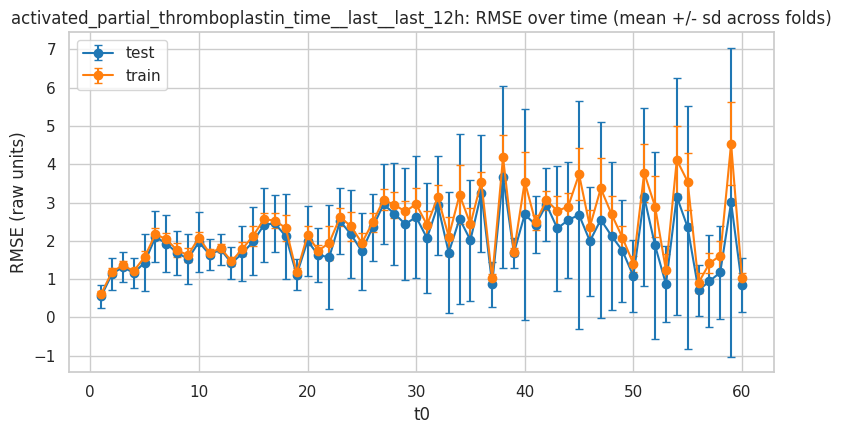

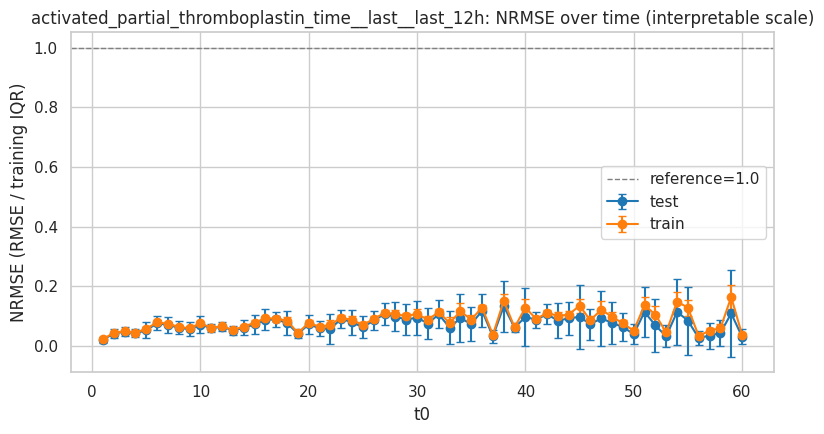

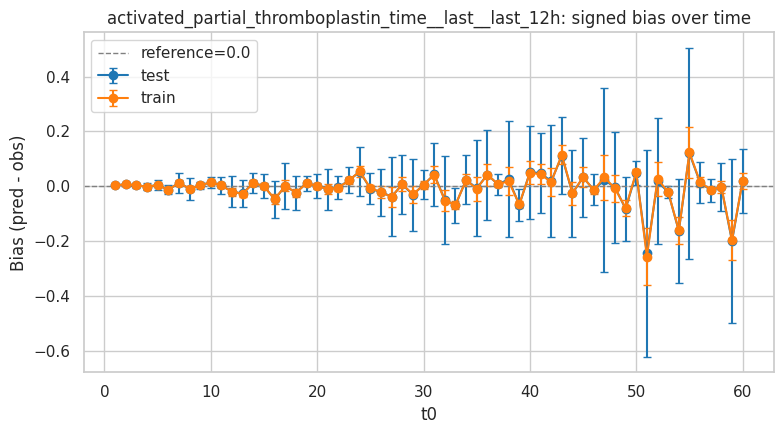

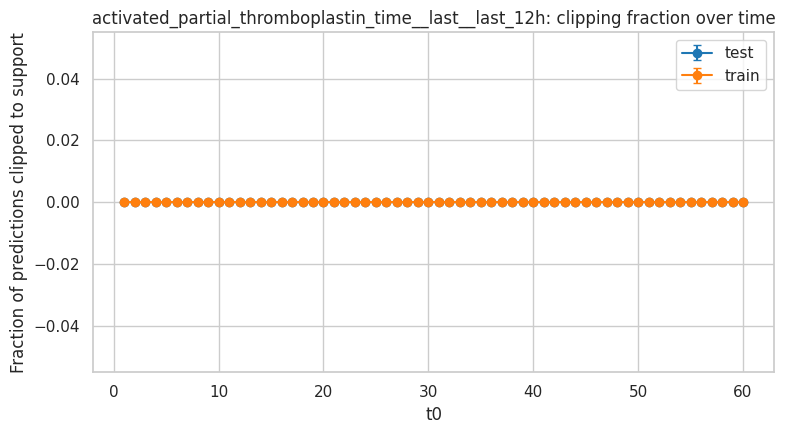

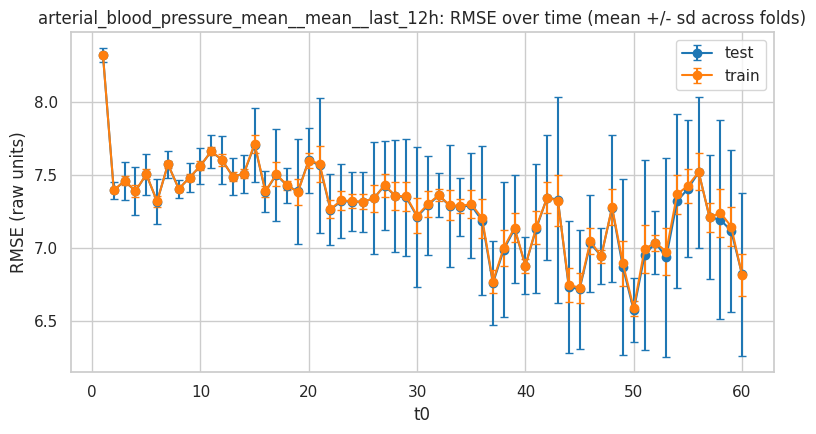

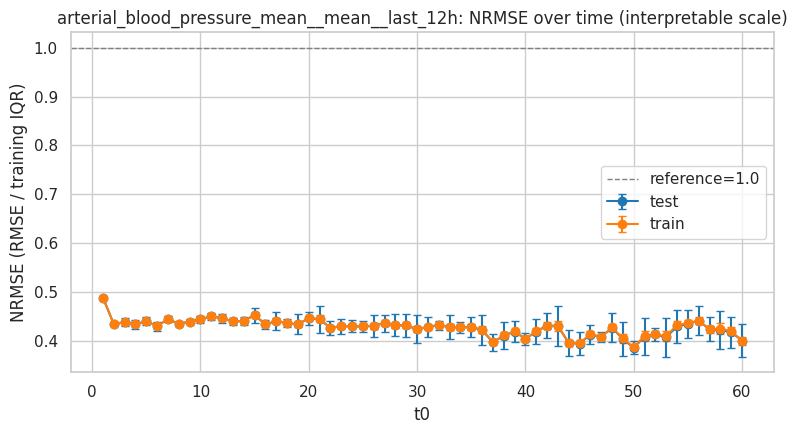

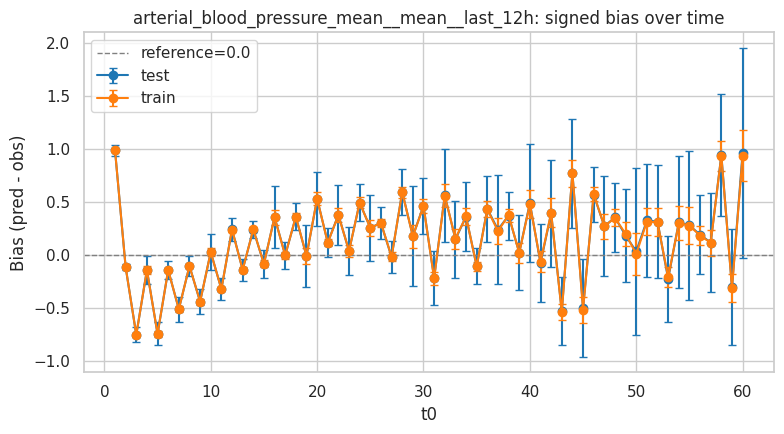

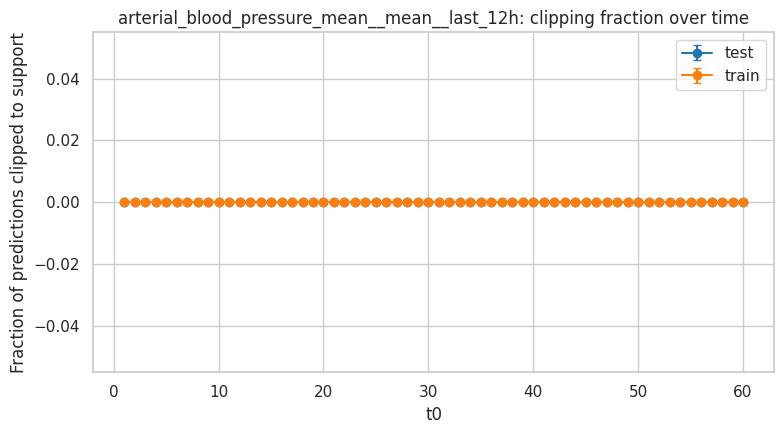

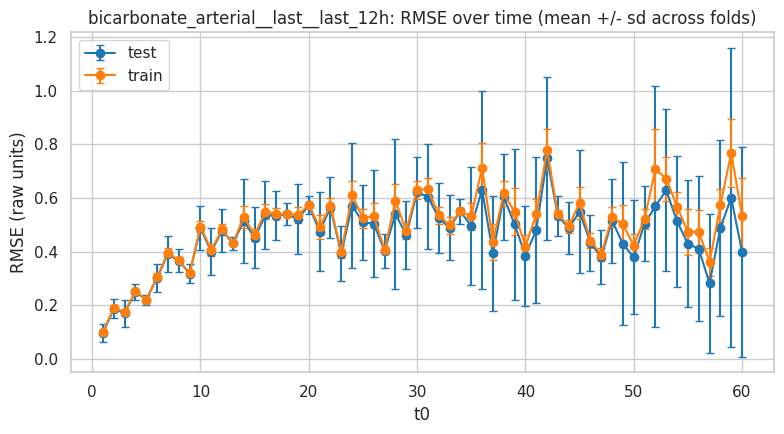

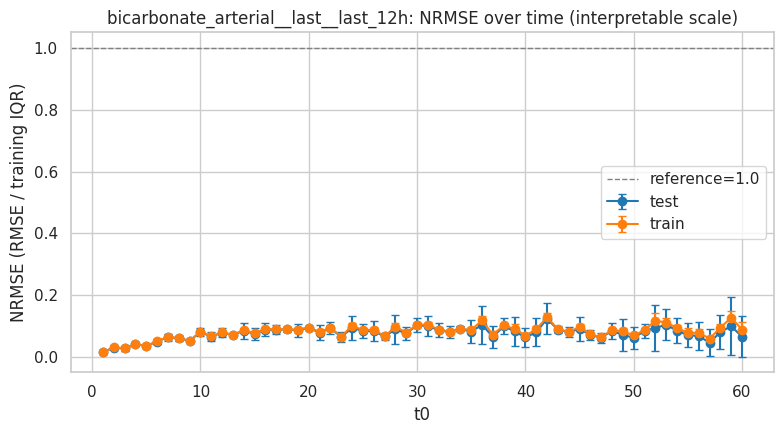

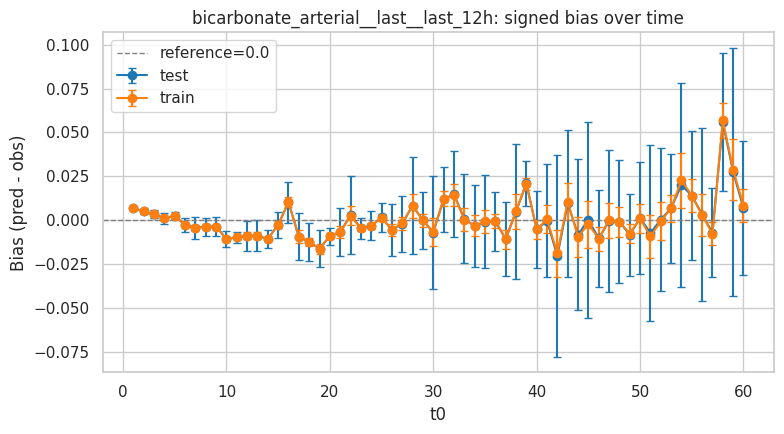

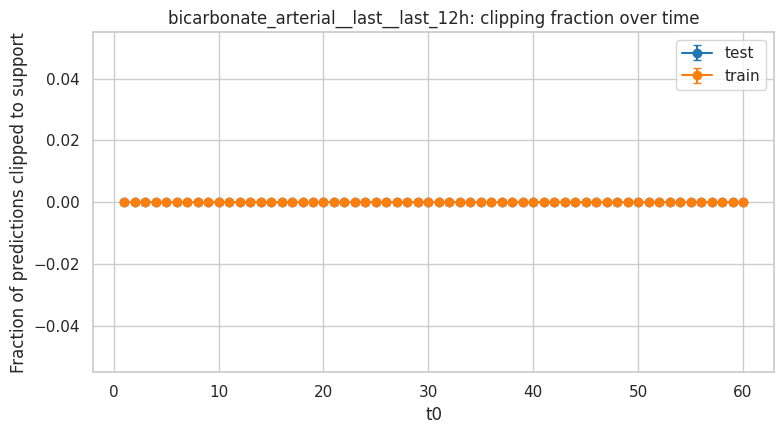

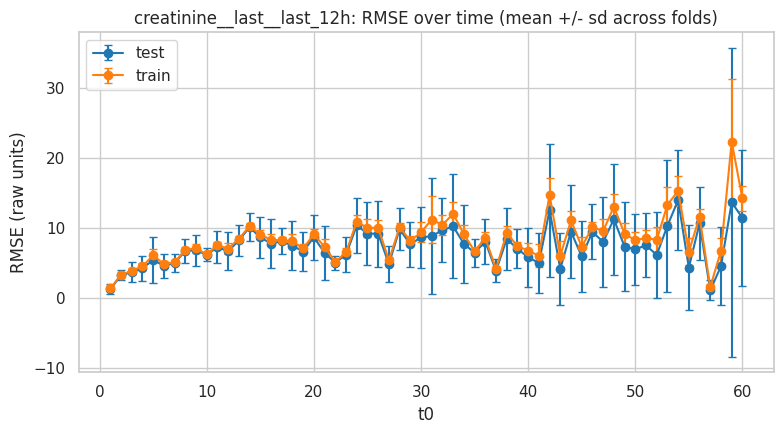

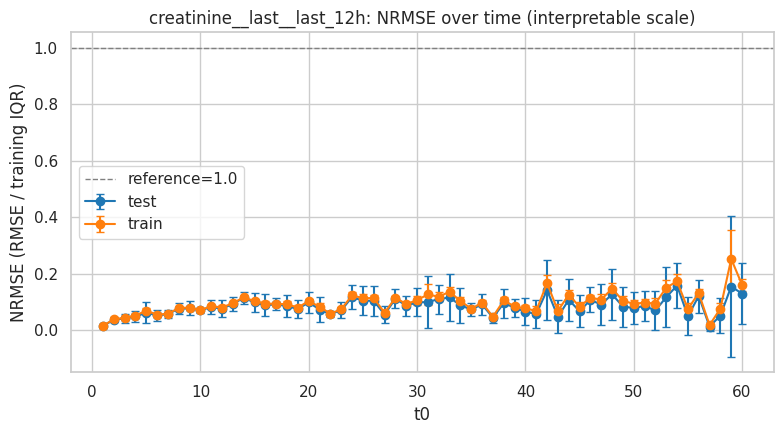

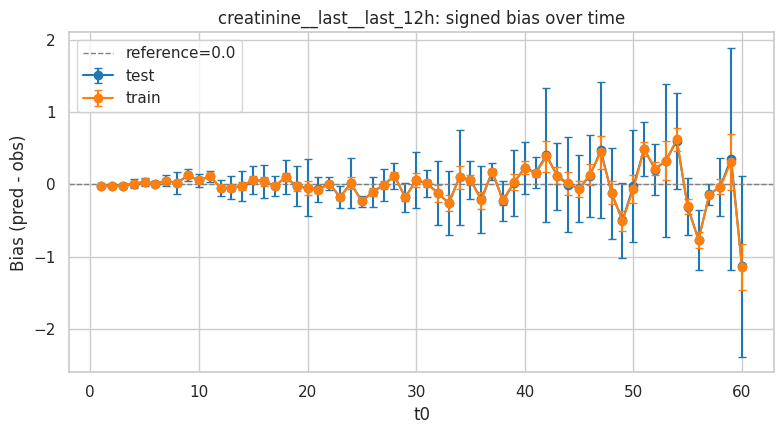

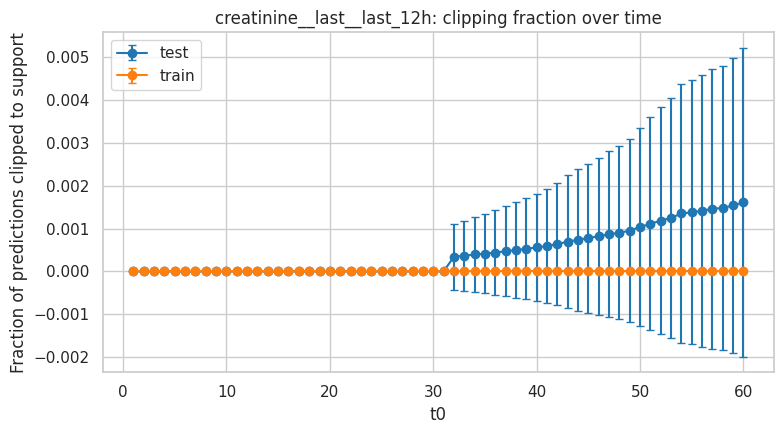

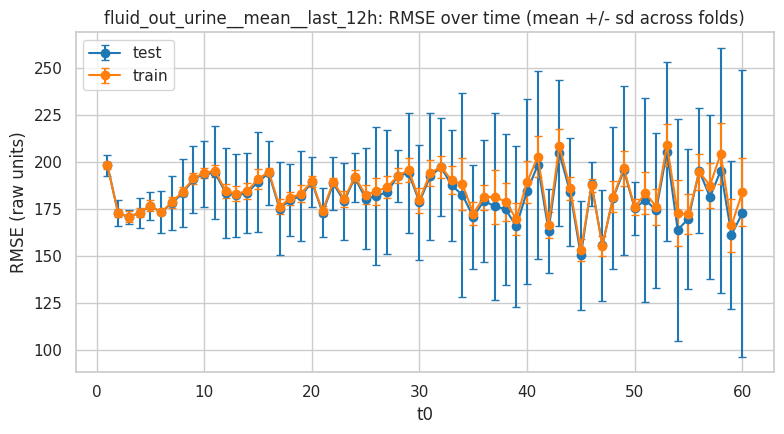

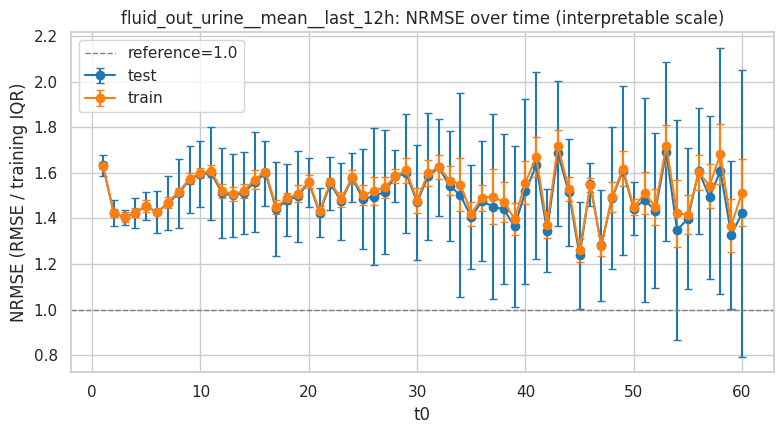

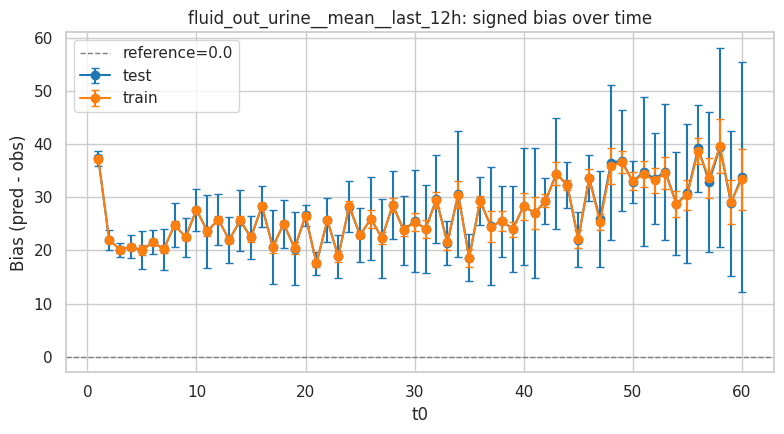

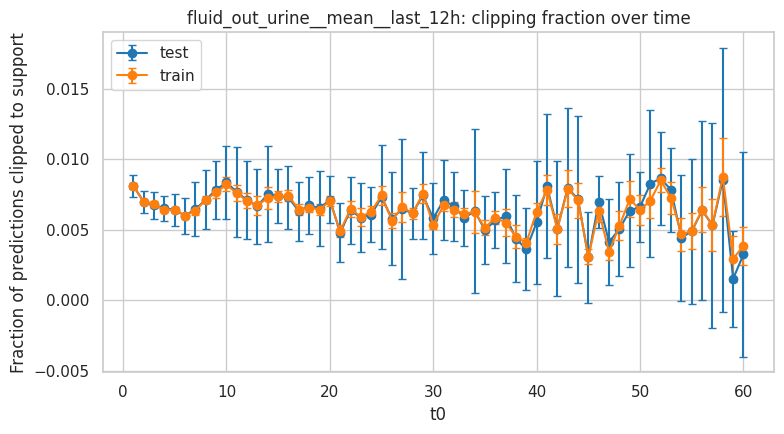

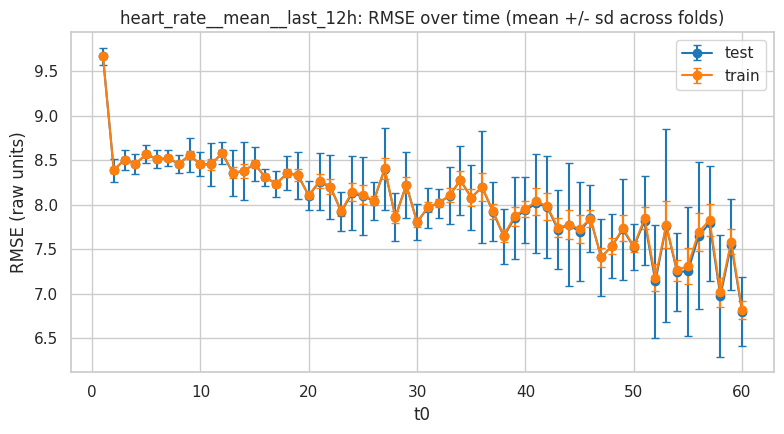

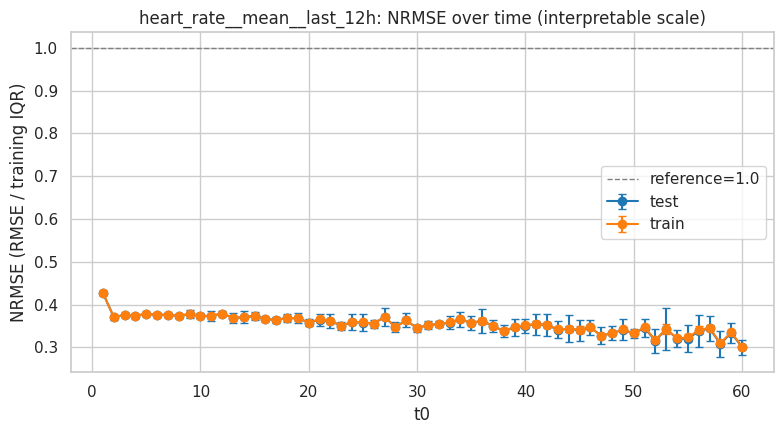

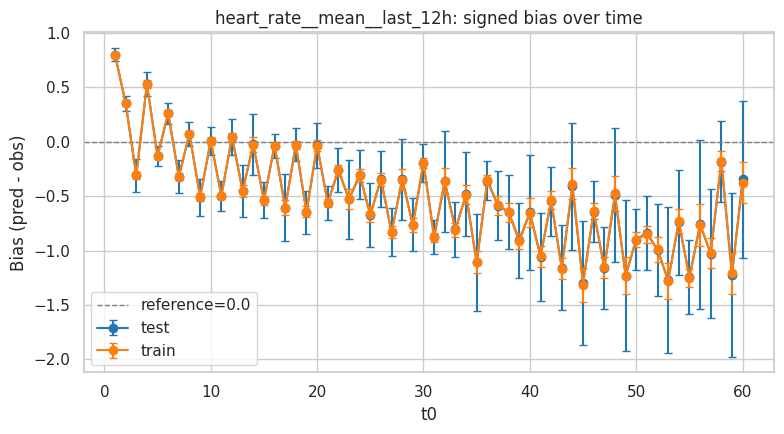

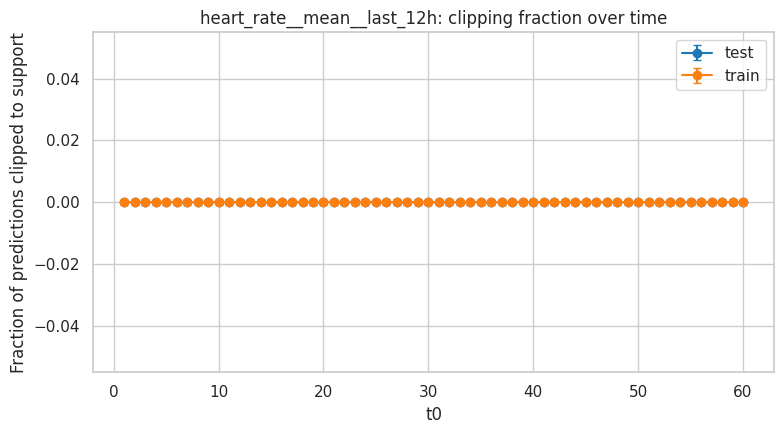

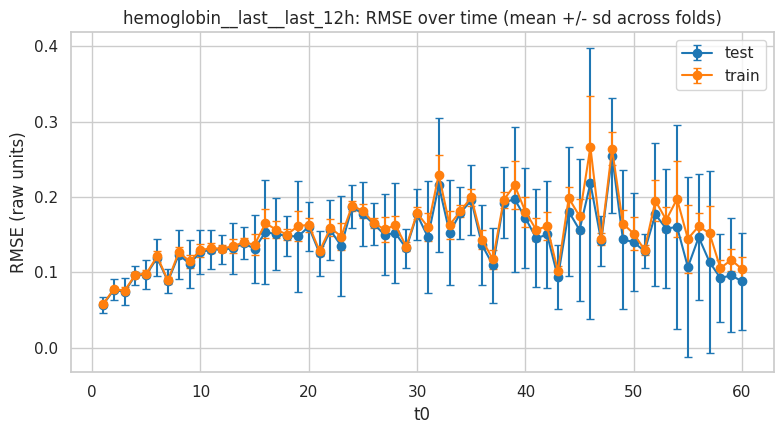

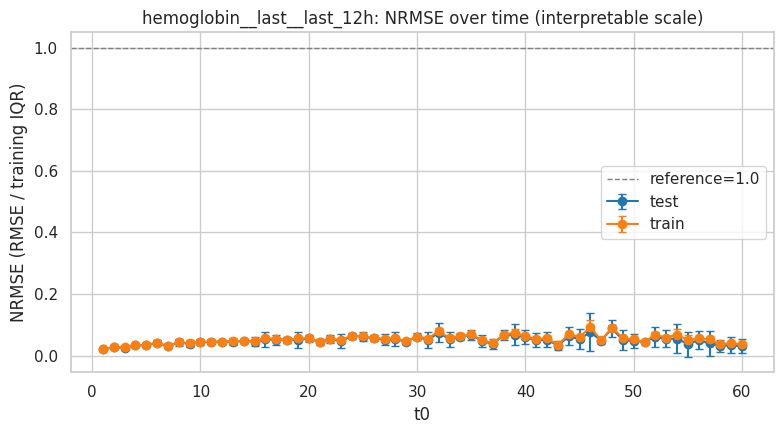

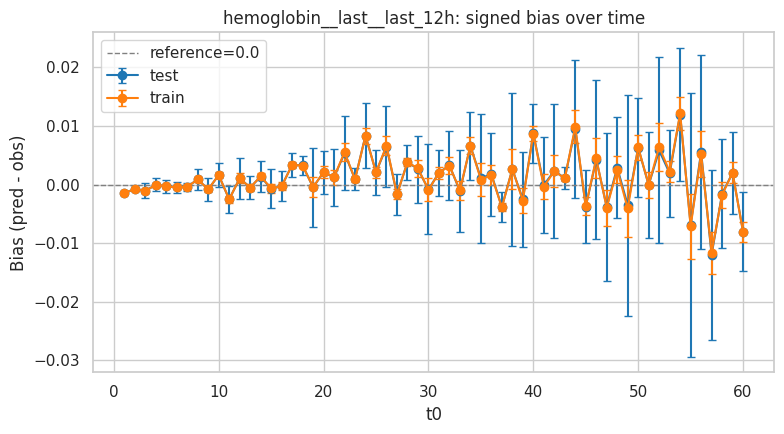

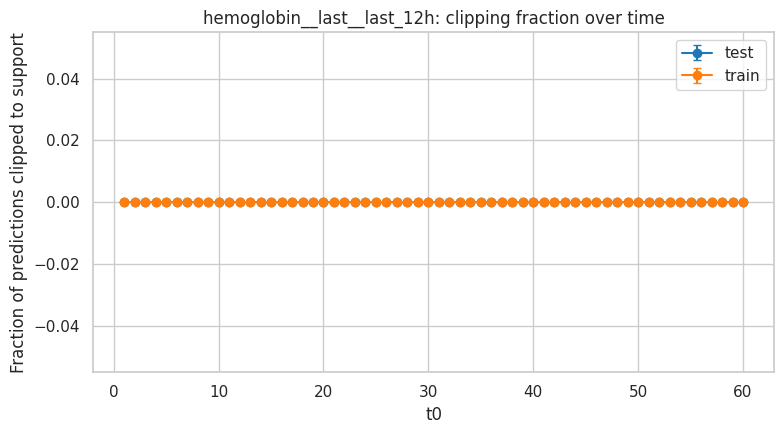

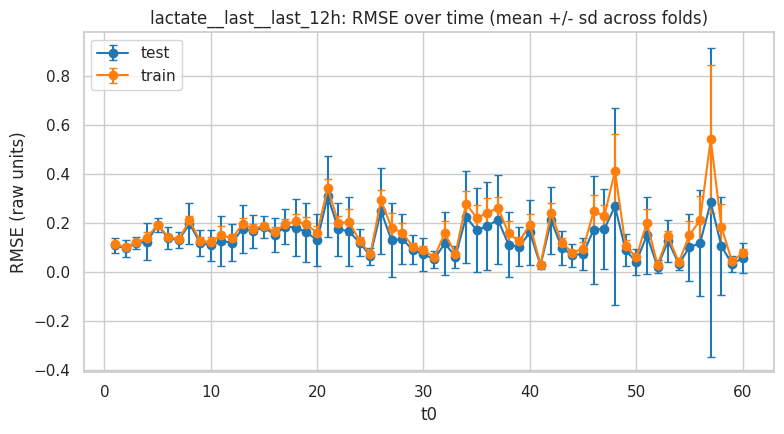

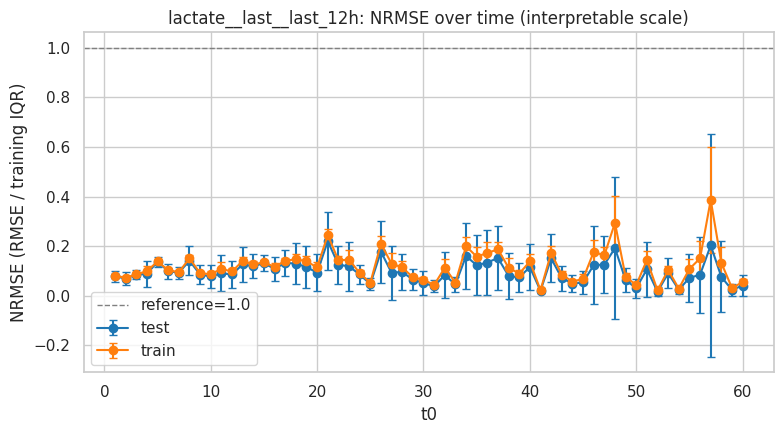

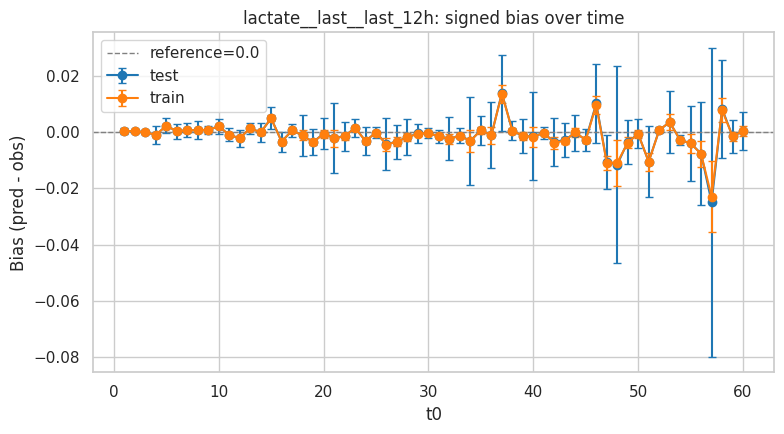

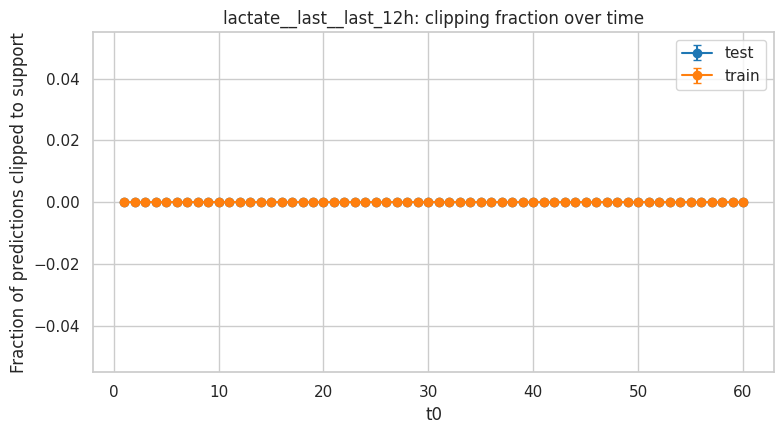

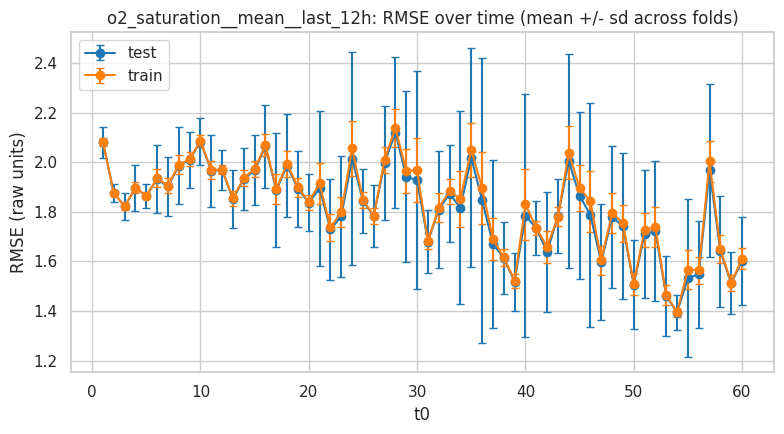

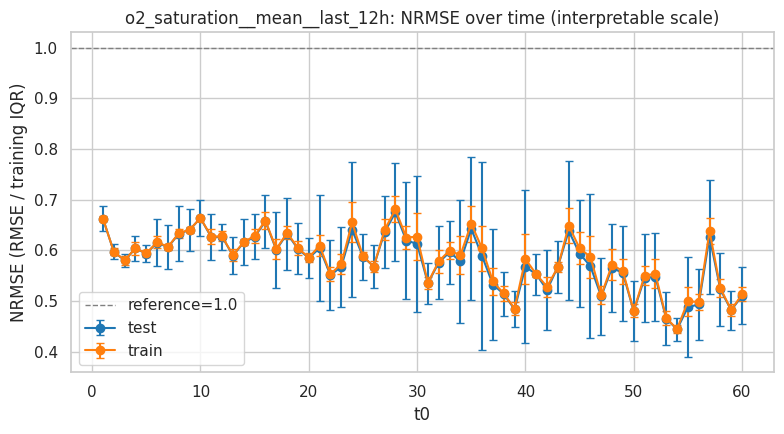

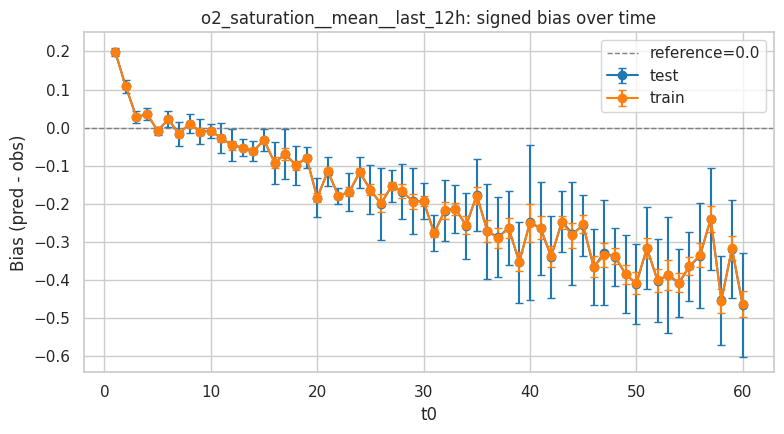

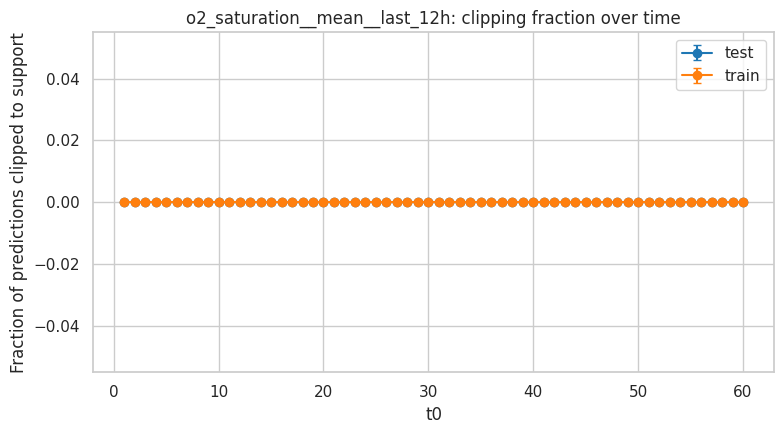

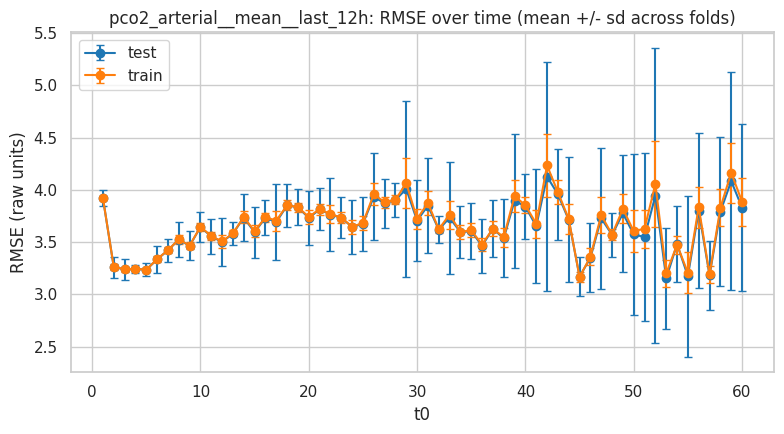

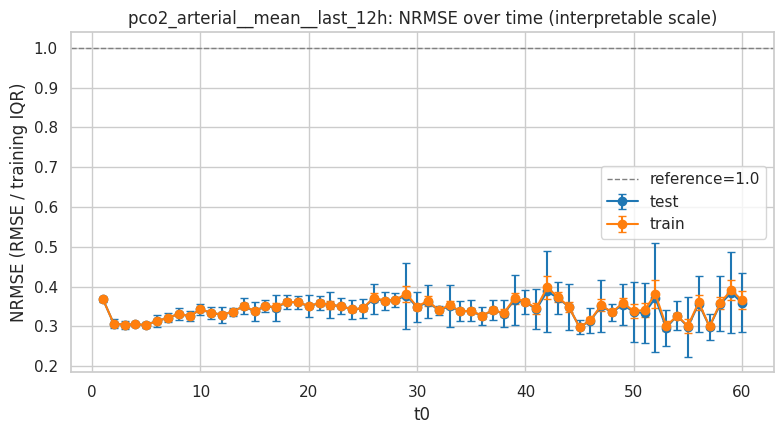

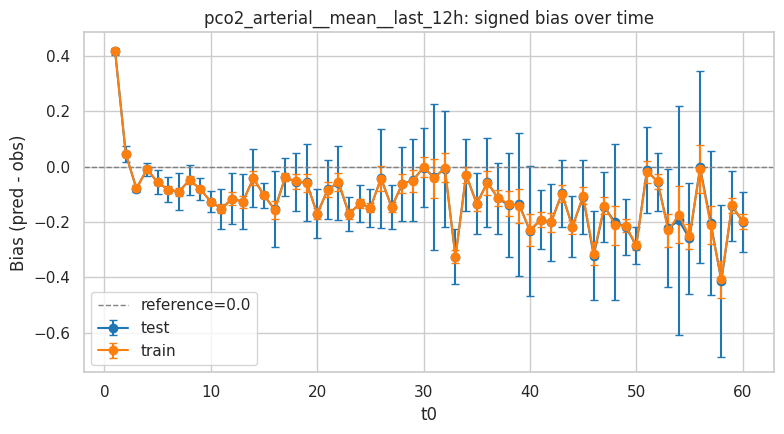

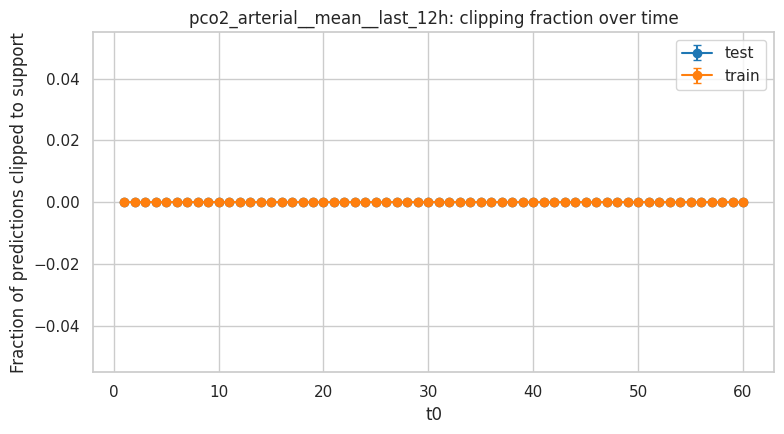

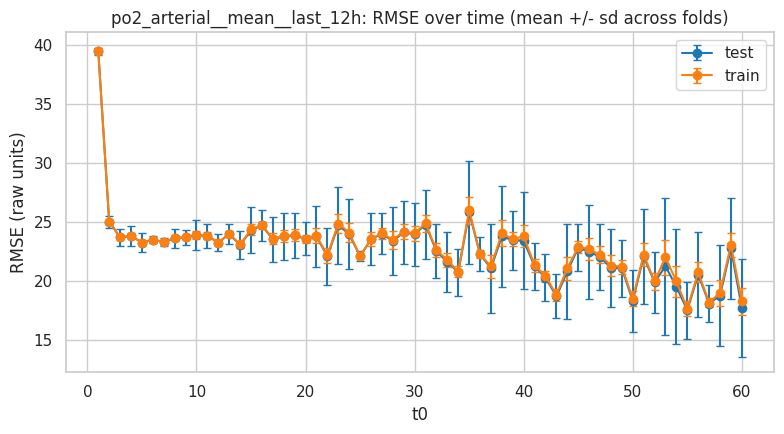

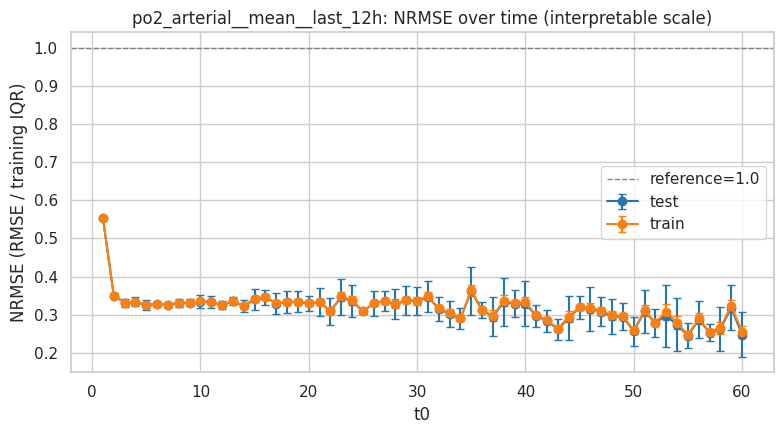

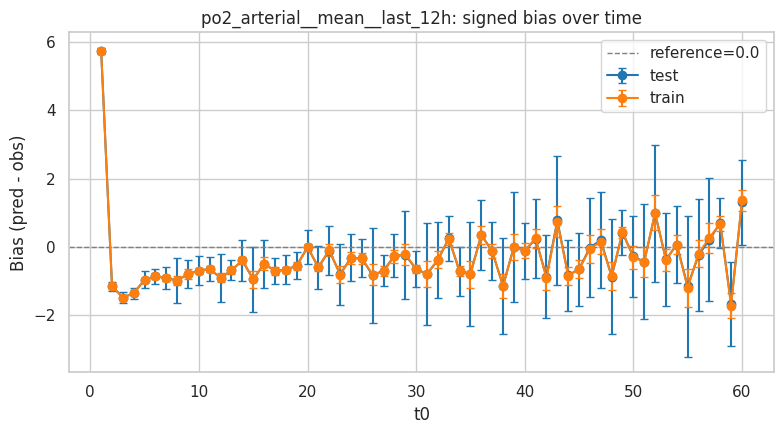

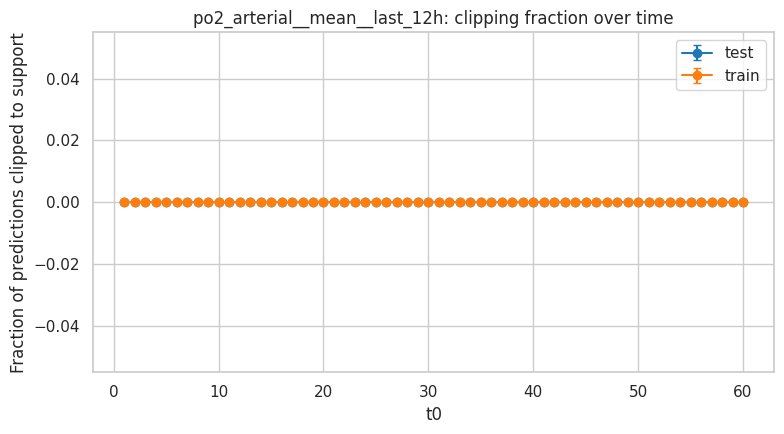

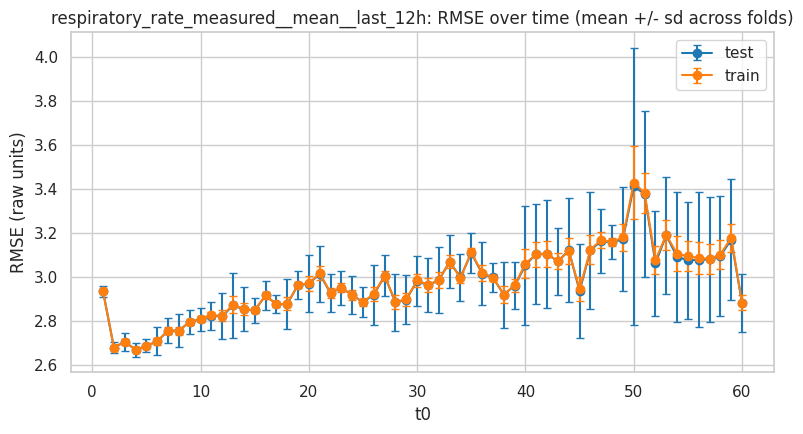

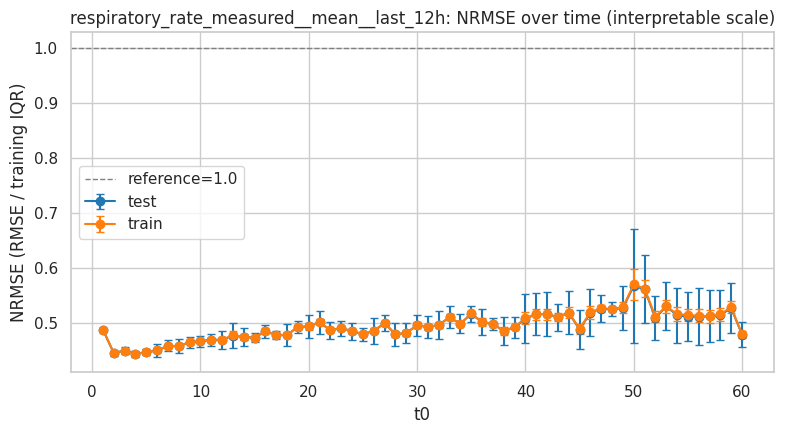

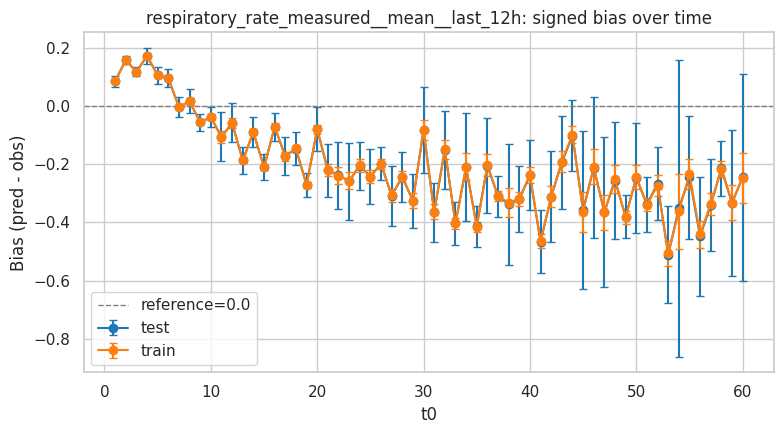

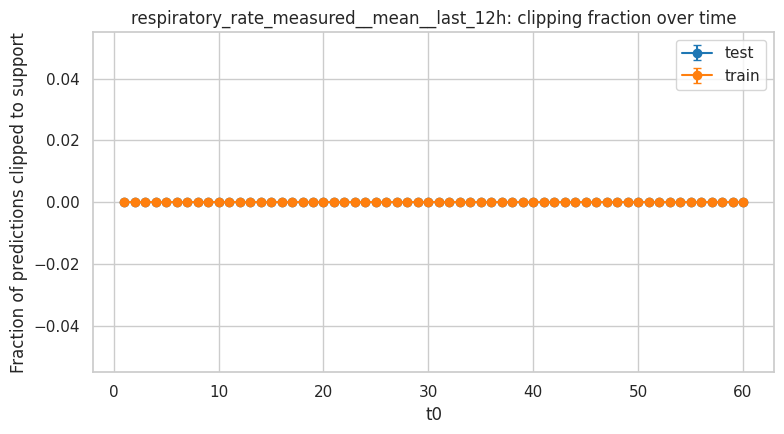

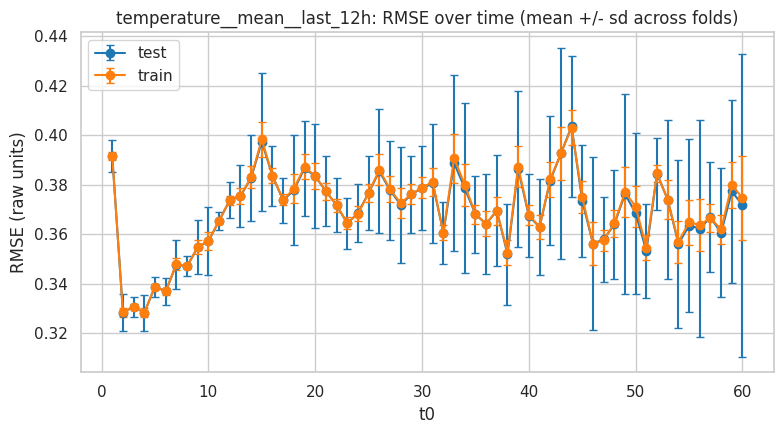

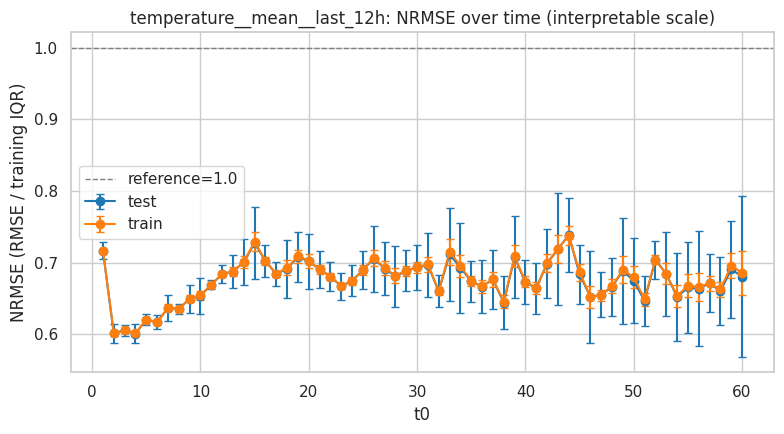

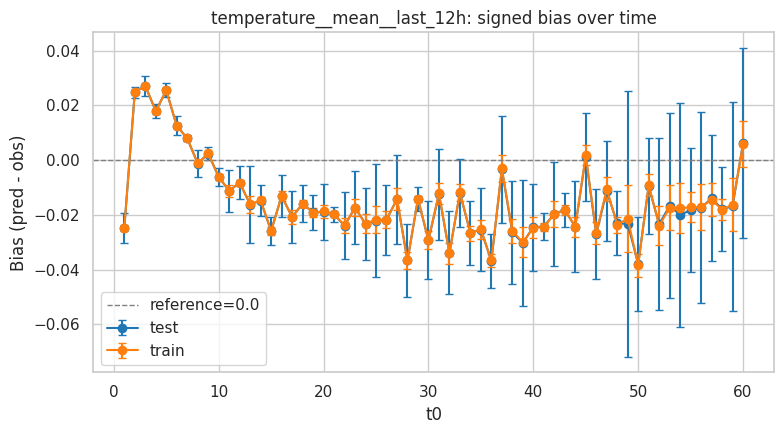

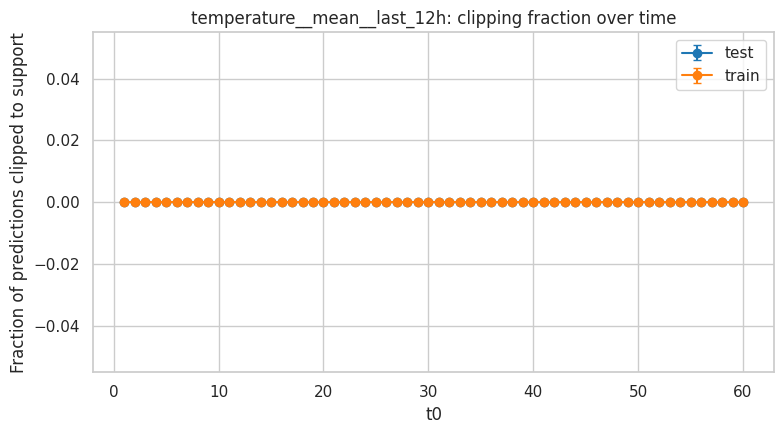

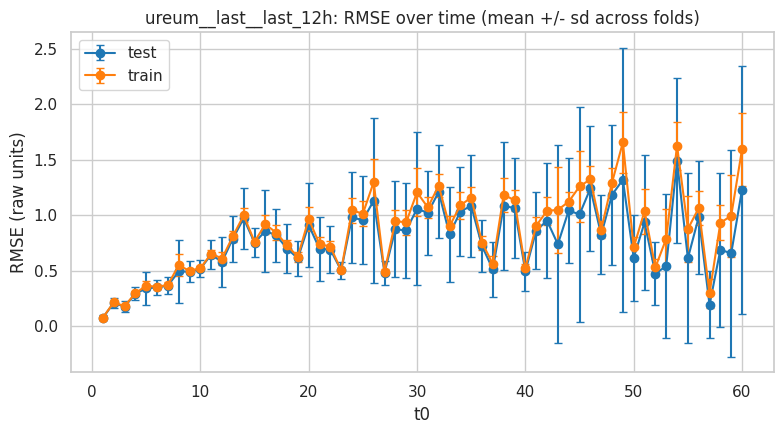

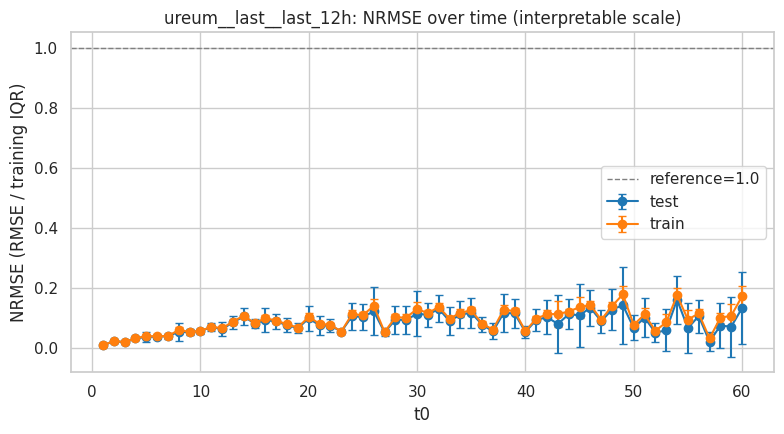

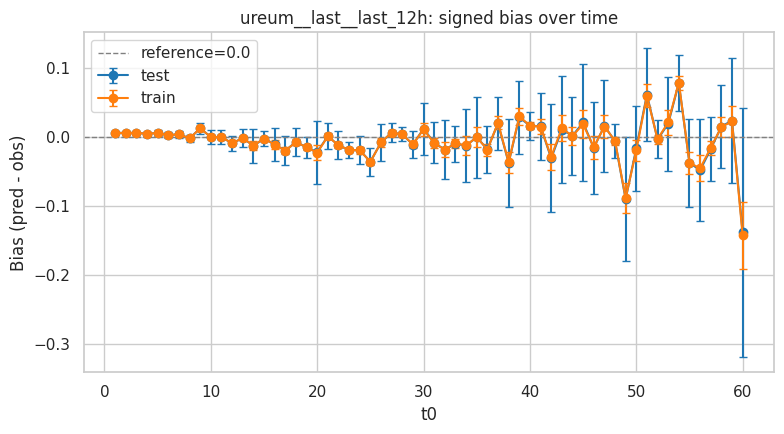

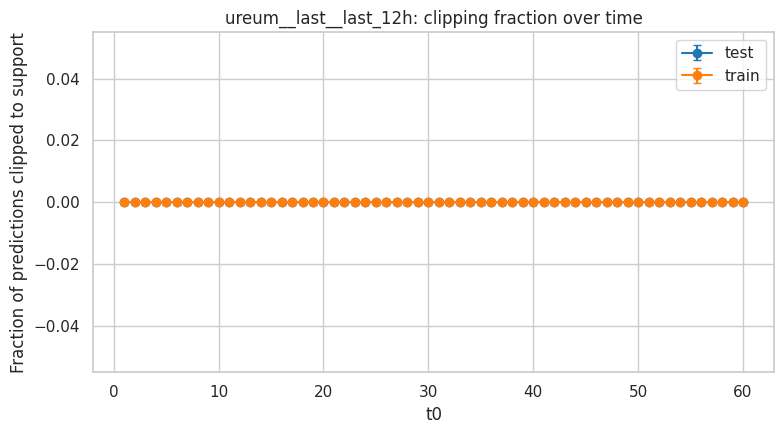

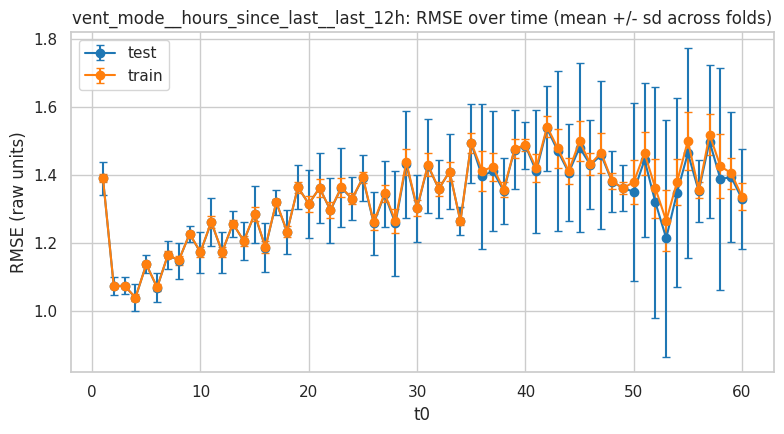

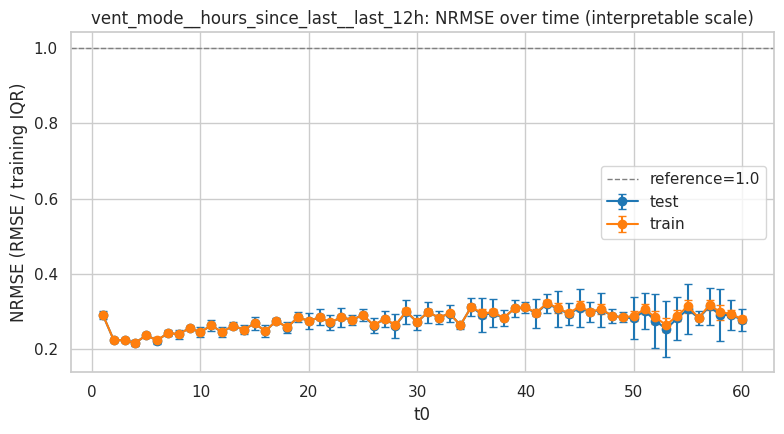

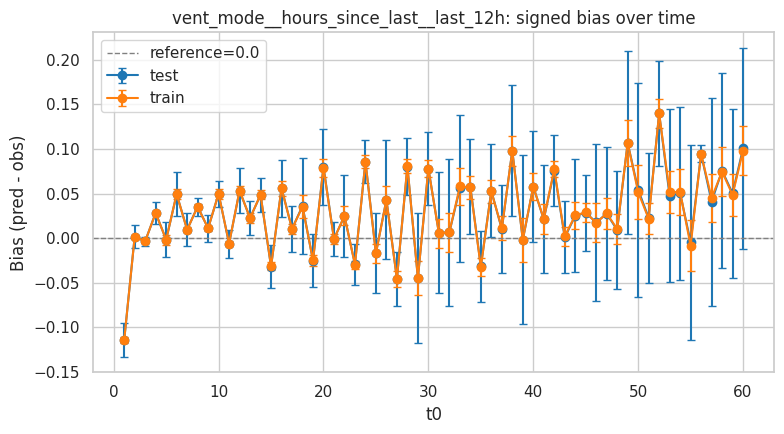

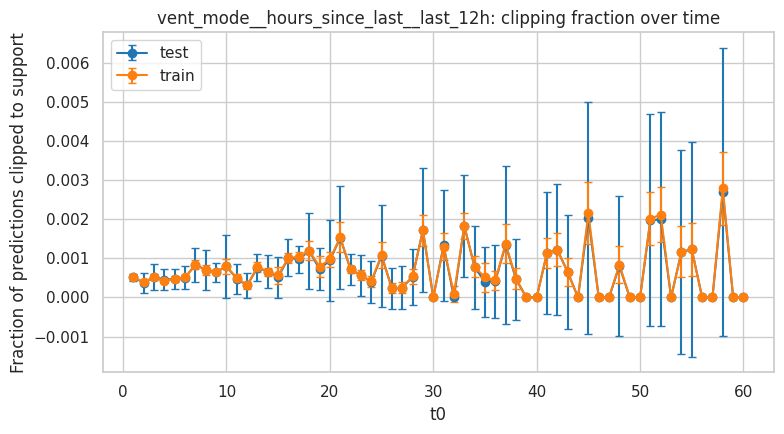

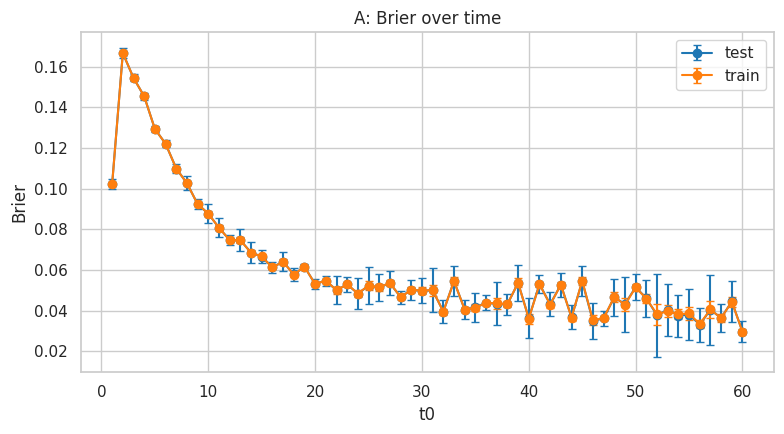

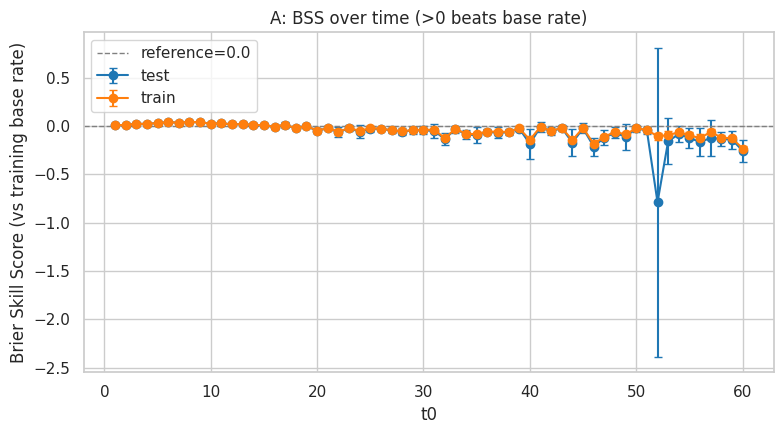

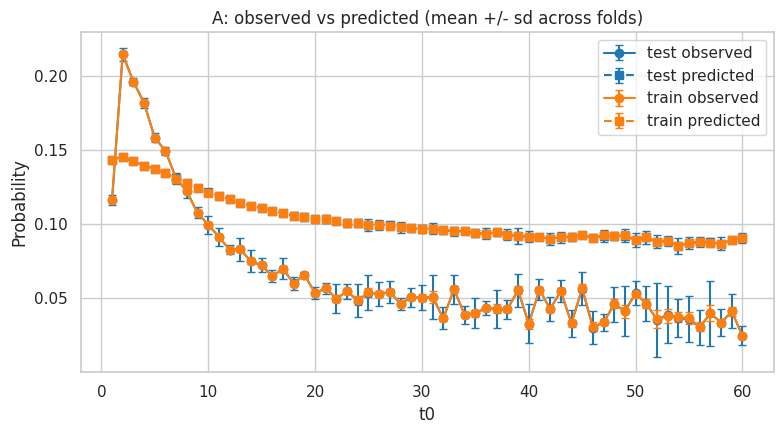

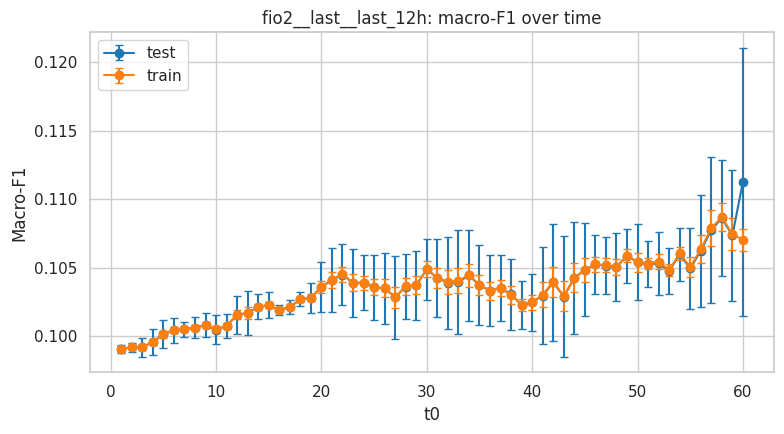

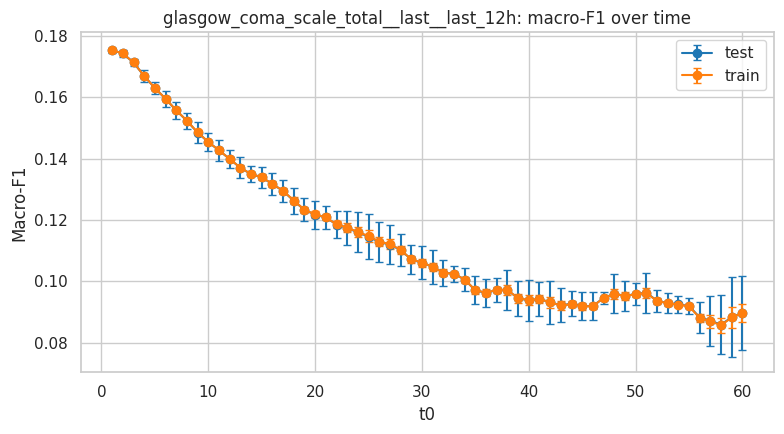

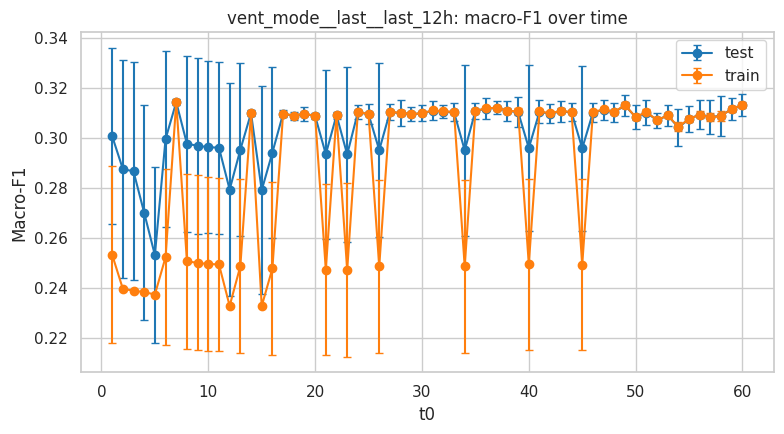

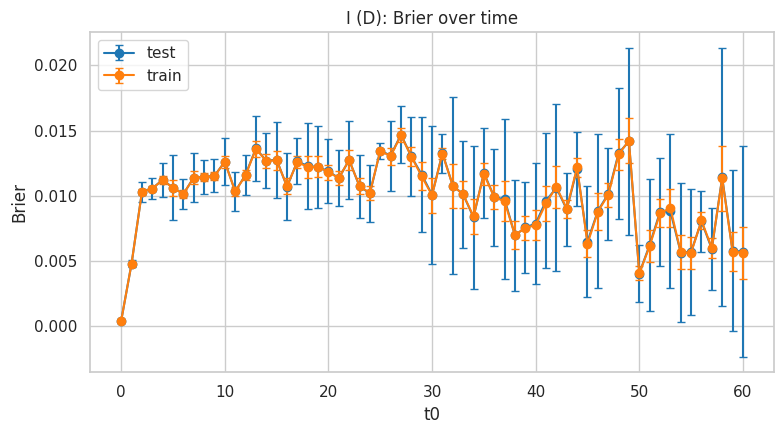

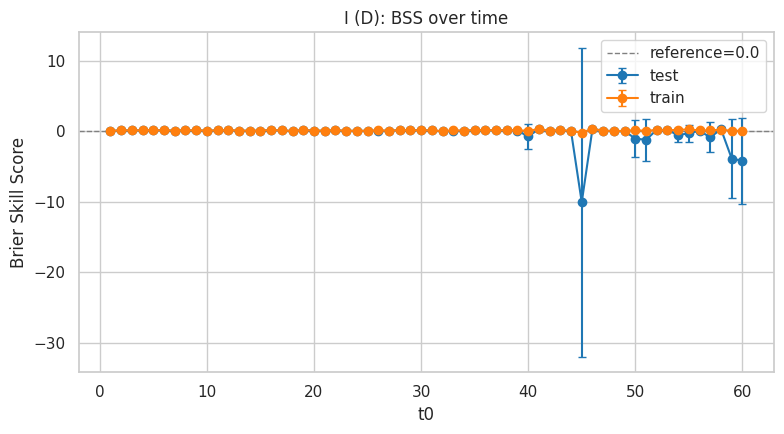

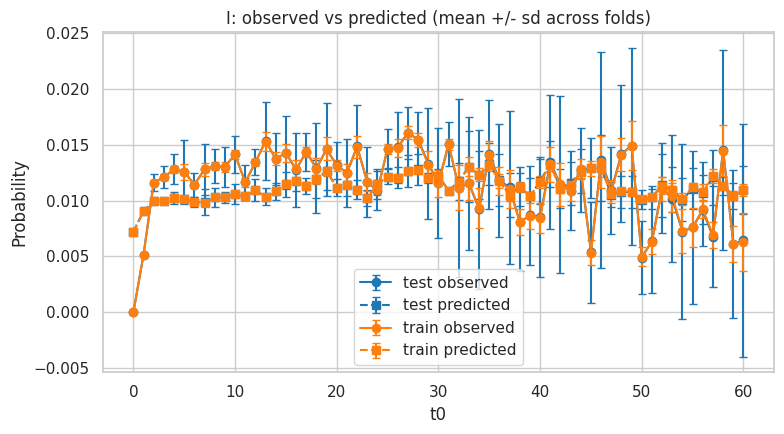

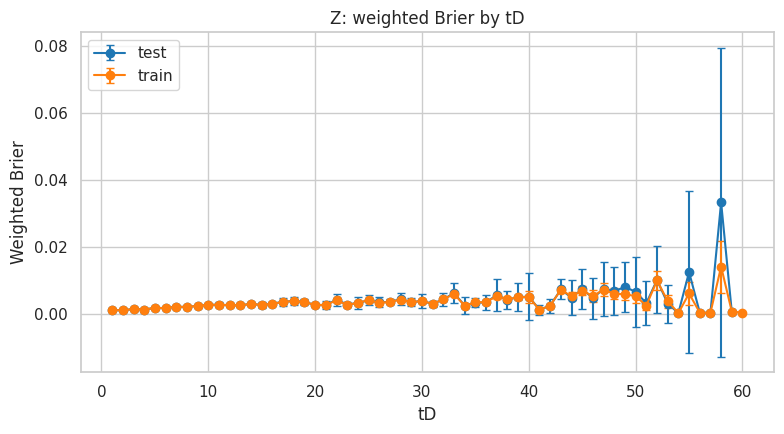

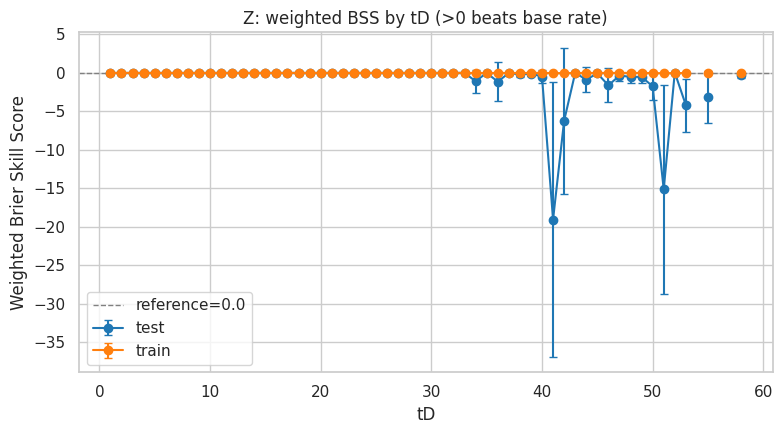

All figures saved under /home/ssimha/Organizing/Organizing-pipeline/Analysis/Model validation/layer1_validation_all_folds/figures


In [15]:
# --- Continuous covariates: raw RMSE, NRMSE (interpretable), bias, clipping --
cont_models = sorted(
    cov_bytime_agg.loc[cov_bytime_agg["target_type"] == "continuous", "model_name"]
    .dropna().unique().tolist()
)
for m in cont_models:
    _plot_metric_by_time(
        cov_bytime_agg, m, "continuous", metric="rmse", x_col=time_name,
        y_label="RMSE (raw units)",
        title=f"{m}: RMSE over time (mean +/- {ERROR_KIND} across folds)",
        save_path=OUTPUT_FIG_DIR / f"{m}__rmse.png",
    )
    _plot_metric_by_time(
        cov_bytime_agg, m, "continuous", metric="nrmse_train_iqr", x_col=time_name,
        y_label="NRMSE (RMSE / training IQR)",
        title=f"{m}: NRMSE over time (interpretable scale)",
        save_path=OUTPUT_FIG_DIR / f"{m}__nrmse.png",
        hline=1.0,
    )
    _plot_metric_by_time(
        cov_bytime_agg, m, "continuous", metric="bias", x_col=time_name,
        y_label="Bias (pred - obs)",
        title=f"{m}: signed bias over time",
        save_path=OUTPUT_FIG_DIR / f"{m}__bias.png",
        hline=0.0,
    )
    if "clipping_fraction__mean" in cov_bytime_agg.columns:
        _plot_metric_by_time(
            cov_bytime_agg, m, "continuous", metric="clipping_fraction",
            x_col=time_name,
            y_label="Fraction of predictions clipped to support",
            title=f"{m}: clipping fraction over time",
            save_path=OUTPUT_FIG_DIR / f"{m}__clipping.png",
        )

# --- Binary covariates (incl. A): Brier, BSS (interpretable), calibration ----
bin_cov_models = sorted(
    cov_bytime_agg.loc[cov_bytime_agg["target_type"] == "binary", "model_name"]
    .dropna().unique().tolist()
)
for m in bin_cov_models:
    _plot_metric_by_time(
        cov_bytime_agg, m, "binary", metric="brier", x_col=time_name,
        y_label="Brier",
        title=f"{m}: Brier over time",
        save_path=OUTPUT_FIG_DIR / f"{m}__brier.png",
    )
    _plot_metric_by_time(
        cov_bytime_agg, m, "binary", metric="bss", x_col=time_name,
        y_label="Brier Skill Score (vs training base rate)",
        title=f"{m}: BSS over time (>0 beats base rate)",
        save_path=OUTPUT_FIG_DIR / f"{m}__bss.png",
        hline=0.0,
    )
    _plot_obs_vs_pred_binary(
        cov_bytime_agg, m, x_col=time_name,
        save_path=OUTPUT_FIG_DIR / f"{m}__obs_vs_pred.png",
    )

# --- Categorical covariates: macro-F1 ----------------------------------------
cat_models = sorted(
    cov_bytime_agg.loc[cov_bytime_agg["target_type"] == "categorical", "model_name"]
    .dropna().unique().tolist()
)
for m in cat_models:
    _plot_metric_by_time(
        cov_bytime_agg, m, "categorical", metric="macro_f1", x_col=time_name,
        y_label="Macro-F1",
        title=f"{m}: macro-F1 over time",
        save_path=OUTPUT_FIG_DIR / f"{m}__macro_f1.png",
    )

# --- I model -----------------------------------------------------------------
_plot_metric_by_time(
    I_bytime_agg, "I", "binary", metric="brier", x_col=time_name,
    y_label="Brier", title="I (D): Brier over time",
    save_path=OUTPUT_FIG_DIR / "I__brier.png",
)
_plot_metric_by_time(
    I_bytime_agg, "I", "binary", metric="bss", x_col=time_name,
    y_label="Brier Skill Score", title="I (D): BSS over time",
    save_path=OUTPUT_FIG_DIR / "I__bss.png", hline=0.0,
)
_plot_obs_vs_pred_binary(
    I_bytime_agg, "I", x_col=time_name,
    save_path=OUTPUT_FIG_DIR / "I__obs_vs_pred.png",
)

# --- Z model -----------------------------------------------------------------
_plot_metric_by_time(
    Z_bytD_agg, "Z", "binary", metric="weighted_brier", x_col="tD",
    y_label="Weighted Brier",
    title="Z: weighted Brier by tD",
    save_path=OUTPUT_FIG_DIR / "Z__weighted_brier.png",
)
_plot_metric_by_time(
    Z_bytD_agg, "Z", "binary", metric="weighted_bss", x_col="tD",
    y_label="Weighted Brier Skill Score",
    title="Z: weighted BSS by tD (>0 beats base rate)",
    save_path=OUTPUT_FIG_DIR / "Z__weighted_bss.png", hline=0.0,
)

print(f"All figures saved under {OUTPUT_FIG_DIR.resolve()}")

## Weighted calibration table for $Z$

Decile-binned calibration on the post-discharge weighted rows. Bins are formed
on the **pooled** prediction column across folds; each bin reports the weighted
observed rate and the weighted mean prediction. Diagonal = perfect calibration.

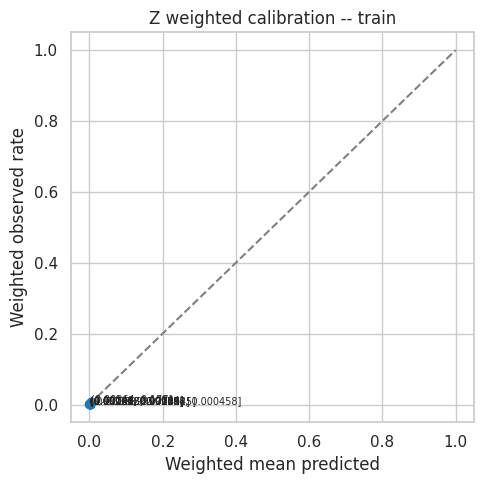

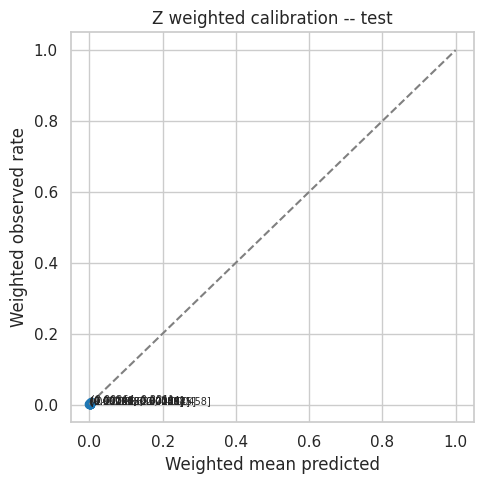

In [16]:
def weighted_calibration_table(df, pred_col="pred_prob", y_col="observed_value",
                               w_col="weight", q=N_CALIB_BINS):
    if df.empty:
        return pd.DataFrame()
    tmp = df[[pred_col, y_col, w_col]].copy()
    tmp["bin"] = pd.qcut(tmp[pred_col], q=q, duplicates="drop")
    rows = []
    for b, g in tmp.groupby("bin", observed=True):
        rows.append({
            "bin": str(b),
            "n_rows": int(len(g)),
            "sum_weights": float(g[w_col].sum()),
            "weighted_observed": weighted_mean(g[y_col], g[w_col]),
            "weighted_predicted": weighted_mean(g[pred_col], g[w_col]),
        })
    return pd.DataFrame(rows)


def plot_calibration(cal_df, title, save_path=None):
    if cal_df.empty:
        print("[skip] empty calibration table")
        return
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.scatter(cal_df["weighted_predicted"], cal_df["weighted_observed"])
    for _, r in cal_df.iterrows():
        plt.annotate(r["bin"], (r["weighted_predicted"], r["weighted_observed"]),
                     fontsize=7)
    plt.xlabel("Weighted mean predicted")
    plt.ylabel("Weighted observed rate")
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    plt.close()


Z_cal_train = weighted_calibration_table(all_Z_rows[all_Z_rows["split"] == "train"])
Z_cal_test = weighted_calibration_table(all_Z_rows[all_Z_rows["split"] == "test"])

plot_calibration(Z_cal_train, "Z weighted calibration -- train",
                 save_path=OUTPUT_FIG_DIR / "Z__calibration_train.png")
plot_calibration(Z_cal_test, "Z weighted calibration -- test",
                 save_path=OUTPUT_FIG_DIR / "Z__calibration_test.png")

## Persistence

Row-level prediction frames as parquet (after `make_parquet_safe`); per-fold
and aggregated summaries as CSV. Identical schemas in both `RUN_MODE` values.

```
layer1_validation_<RUN_MODE>/
    data/                # row-level predictions (parquet)
    summaries/           # per-fold and aggregated metrics (CSV)
    figures/             # PNGs from the plot cells
```

In [17]:
# Row-level (parquet, with safe dtypes for mixed-object columns)
make_parquet_safe(all_cov_rows).to_parquet(
    OUTPUT_DATA_DIR / "all_cov_rows.parquet", index=False)
make_parquet_safe(all_I_rows).to_parquet(
    OUTPUT_DATA_DIR / "all_I_rows.parquet", index=False)
make_parquet_safe(all_Z_rows).to_parquet(
    OUTPUT_DATA_DIR / "all_Z_rows.parquet", index=False)

# Per-fold metric tables
cov_perfold_overall.to_csv(OUTPUT_SUMMARY_DIR / "cov_perfold_overall.csv", index=False)
I_perfold_overall.to_csv(OUTPUT_SUMMARY_DIR / "I_perfold_overall.csv", index=False)
Z_perfold_overall.to_csv(OUTPUT_SUMMARY_DIR / "Z_perfold_overall.csv", index=False)

cov_perfold_by_time.to_csv(OUTPUT_SUMMARY_DIR / "cov_perfold_by_time.csv", index=False)
I_perfold_by_time.to_csv(OUTPUT_SUMMARY_DIR / "I_perfold_by_time.csv", index=False)
Z_perfold_by_tD.to_csv(OUTPUT_SUMMARY_DIR / "Z_perfold_by_tD.csv", index=False)

# Aggregated metric tables (mean / sd / se / k across folds)
cov_overall_agg.to_csv(OUTPUT_SUMMARY_DIR / "cov_overall_agg.csv", index=False)
I_overall_agg.to_csv(OUTPUT_SUMMARY_DIR / "I_overall_agg.csv", index=False)
Z_overall_agg.to_csv(OUTPUT_SUMMARY_DIR / "Z_overall_agg.csv", index=False)

cov_bytime_agg.to_csv(OUTPUT_SUMMARY_DIR / "cov_bytime_agg.csv", index=False)
I_bytime_agg.to_csv(OUTPUT_SUMMARY_DIR / "I_bytime_agg.csv", index=False)
Z_bytD_agg.to_csv(OUTPUT_SUMMARY_DIR / "Z_bytD_agg.csv", index=False)

# Z calibration
Z_cal_train.to_csv(OUTPUT_SUMMARY_DIR / "Z_calibration_train.csv", index=False)
Z_cal_test.to_csv(OUTPUT_SUMMARY_DIR / "Z_calibration_test.csv", index=False)

print(f"All outputs written under {OUTPUT_ROOT.resolve()}")

All outputs written under /home/ssimha/Organizing/Organizing-pipeline/Analysis/Model validation/layer1_validation_all_folds


## Inspection checklist

Before drawing substantive conclusions:

1. Are eligible-row counts (`n` columns in the per-fold tables) plausible for
   each covariate? Sparse rows produce noisy metrics regardless of model
   quality.
2. Is **train** performance meaningfully better than **test**? A large gap
   suggests overfitting; no gap suggests either a robust fit or that the
   dataset is large enough that train and test are statistically interchangeable.
3. Does any **specific time window** show sharp deterioration? This often
   marks covariates whose support shifts over the ICU stay.
4. Does **A**'s calibration drift late in follow-up? Late-time A misfit
   particularly damages downstream g-formula because it attenuates contrasts
   under intervention.
5. Does **I** look overly optimistic in rare-event strata? Censoring/discharge
   probabilities near 0 or 1 destabilise the Z-row construction.
6. Does **weighted Z calibration** look reasonable across discharge times $t_D$?
   Systematic over- or under-prediction in late $t_D$ reflects either Z model
   misspecification or a weighted-rows construction that loses precision when
   weights become extreme.
7. Are any continuous predicted means **clipped** more than a few percent of the
   time? The `clipping_fraction` column flags this. A high fraction indicates
   either bound mis-specification or a model whose conditional mean routinely
   leaves the support.
8. For categorical components, check `n_unseen_excluded`. Non-zero values flag
   train-test category mismatch — typically a coding inconsistency rather than
   a modelling problem, but worth fixing at source.

#### Per-component held-out validation metric, computed by averaging per-time-stratum metrics (where stratum n≥50n \geq 50
#### n≥50) within each fold and then taking mean ± SE across folds.

In [18]:
# =============================================================================
# averaged over time within each held-out fold, then averaged over folds; the ±0.006 is the standard error of that fold-mean across the 5 folds.
# Framing B' summary table for rebuttal
# Per-stratum metric where n_t >= MIN_STRATUM_N, equal-weight averaged across
# surviving strata, then mean +/- SE across folds.
# =============================================================================
MIN_STRATUM_N = 50   # minimum rows in a time stratum for it to count
                     # (raise to 100 for a stricter bar, lower for sparser data)

# Headline metric per component family + arrow direction
METRIC_BY_FAMILY = {
    "continuous":  ("nrmse_train_iqr", "lower is better"),
    "binary":      ("bss",             "higher is better"),
    "categorical": ("macro_f1",        "higher is better"),
}
Z_METRIC = ("weighted_bss", "higher is better")


def _summarise_one_component(perfold_by_time, model_name, target_type,
                             metric, n_col="n", min_n=MIN_STRATUM_N):
    # Returns a dict with mean / se / n_strata aggregated across folds, for
    # one (model, split) cell. Caller filters by split before passing in.
    if perfold_by_time.empty:
        return None
    sub = perfold_by_time[
        (perfold_by_time["model_name"] == model_name)
        & (perfold_by_time["target_type"] == target_type)
    ].copy()
    if sub.empty or metric not in sub.columns:
        return None
    # Keep only strata that pass the size threshold and have a valid metric
    sub = sub[(sub[n_col] >= min_n) & sub[metric].notna()].copy()
    if sub.empty:
        return {"mean": np.nan, "se": np.nan,
                "n_strata_avg": 0.0, "n_folds": 0}

    # Per-fold equal-weight average across surviving time strata
    per_fold = sub.groupby("fold").agg(
        m=(metric, "mean"),
        n_strata=(metric, "size"),
    ).reset_index()
    vals = per_fold["m"].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    k = len(vals)
    if k == 0:
        return {"mean": np.nan, "se": np.nan,
                "n_strata_avg": float(per_fold["n_strata"].mean()),
                "n_folds": 0}
    mean = float(np.mean(vals))
    se = float(np.std(vals, ddof=1) / np.sqrt(k)) if k > 1 else np.nan
    return {
        "mean": mean,
        "se": se,
        "n_strata_avg": float(per_fold["n_strata"].mean()),
        "n_folds": k,
    }


# -----------------------------------------------------------------------------
# Build one row per component (covariates + I + Z), train and test side by side
# -----------------------------------------------------------------------------
rows = []

# L covariates (continuous, binary, categorical)
for cov, ctype in zip(covnames, covtypes):
    if ctype in {"normal", "bounded normal", "truncated normal",
                 "zero-inflated normal", "poisson", "custom"}:
        family = "continuous"
    elif ctype in {"binary", "absorbing"}:
        family = "binary"
    elif ctype == "categorical":
        family = "categorical"
    else:
        continue
    metric, direction = METRIC_BY_FAMILY[family]

    row = {"component": cov, "family": family,
           "metric": metric, "direction": direction}
    for split in ("train", "test"):
        s = cov_perfold_by_time[cov_perfold_by_time["split"] == split]
        res = _summarise_one_component(s, cov, family, metric)
        if res is None:
            row[f"{split}_mean"] = np.nan
            row[f"{split}_se"] = np.nan
            row[f"{split}_n_strata"] = 0
        else:
            row[f"{split}_mean"] = res["mean"]
            row[f"{split}_se"] = res["se"]
            row[f"{split}_n_strata"] = res["n_strata_avg"]
    rows.append(row)

# I model
metric, direction = METRIC_BY_FAMILY["binary"]
row = {"component": "I (D)", "family": "binary",
       "metric": metric, "direction": direction}
for split in ("train", "test"):
    s = I_perfold_by_time[I_perfold_by_time["split"] == split]
    res = _summarise_one_component(s, "I", "binary", metric)
    row[f"{split}_mean"] = res["mean"] if res else np.nan
    row[f"{split}_se"] = res["se"] if res else np.nan
    row[f"{split}_n_strata"] = res["n_strata_avg"] if res else 0
rows.append(row)

# Z model -- weighted BSS by tD; n column is n_rows here
metric, direction = Z_METRIC
row = {"component": "Z", "family": "binary (weighted)",
       "metric": metric, "direction": direction}
for split in ("train", "test"):
    s = Z_perfold_by_tD[Z_perfold_by_tD["split"] == split]
    res = _summarise_one_component(s, "Z", "binary", metric, n_col="n_rows")
    row[f"{split}_mean"] = res["mean"] if res else np.nan
    row[f"{split}_se"] = res["se"] if res else np.nan
    row[f"{split}_n_strata"] = res["n_strata_avg"] if res else 0
rows.append(row)

summary_B = pd.DataFrame(rows)

# -----------------------------------------------------------------------------
# Rebuttal-friendly formatting: "0.123 ± 0.045"
# -----------------------------------------------------------------------------
def _fmt(mean, se, decimals=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(se):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {se:.{decimals}f}"

summary_B_pretty = pd.DataFrame({
    "Component": summary_B["component"],
    "Metric": summary_B["metric"],
    "Direction": summary_B["direction"],
    "Train": [_fmt(m, s) for m, s in zip(summary_B["train_mean"],
                                         summary_B["train_se"])],
    "Held-out": [_fmt(m, s) for m, s in zip(summary_B["test_mean"],
                                            summary_B["test_se"])],
    "Avg # time strata (held-out)": summary_B["test_n_strata"].round(1),
})

# Persist
summary_B.to_csv(OUTPUT_SUMMARY_DIR / "rebuttal_summary_framingB.csv",
                 index=False)
summary_B_pretty.to_csv(OUTPUT_SUMMARY_DIR / "rebuttal_summary_framingB_pretty.csv",
                        index=False)

print(f"Threshold: n_t >= {MIN_STRATUM_N} per time stratum")
print(f"Folds: {summary_B[['train_n_strata', 'test_n_strata']].notna().any().any()}")
print()
print(summary_B_pretty.to_string(index=False))

Threshold: n_t >= 50 per time stratum
Folds: True

                                            Component          Metric        Direction          Train       Held-out  Avg # time strata (held-out)
                            vent_mode__last__last_12h        macro_f1 higher is better  0.289 ± 0.001  0.303 ± 0.001                          60.0
                vent_mode__hours_since_last__last_12h nrmse_train_iqr  lower is better  0.279 ± 0.001  0.277 ± 0.005                          60.0
                        pco2_arterial__mean__last_12h nrmse_train_iqr  lower is better  0.344 ± 0.000  0.343 ± 0.006                          60.0
                         po2_arterial__mean__last_12h nrmse_train_iqr  lower is better  0.320 ± 0.001  0.318 ± 0.003                          60.0
                                 fio2__last__last_12h        macro_f1 higher is better  0.103 ± 0.000  0.103 ± 0.001                          60.0
                        o2_saturation__mean__last_12h nrmse_train_i

In [19]:
MIN_STRATUM_N=50
# =============================================================================
# Framing B' summary by time window
# Per-stratum metric where n_t >= MIN_STRATUM_N, equal-weight averaged within
# each time window per fold, then mean +/- SE across folds.
# Default: cumulative windows [0, 15], [0, 30], [0, 45], [0, 60].
# =============================================================================
TIME_WINDOWS = [(0, 15), (0, 30), (0, 45), (0, 60)]   # inclusive on both ends


def _summarise_one_component_in_window(perfold_by_time, model_name,
                                       target_type, metric,
                                       t_col, t_lo, t_hi,
                                       n_col="n", min_n=MIN_STRATUM_N):
    # Same aggregator as before but restricted to t_lo <= t <= t_hi.
    if perfold_by_time.empty:
        return None
    sub = perfold_by_time[
        (perfold_by_time["model_name"] == model_name)
        & (perfold_by_time["target_type"] == target_type)
        & (perfold_by_time[t_col] >= t_lo)
        & (perfold_by_time[t_col] <= t_hi)
    ].copy()
    if sub.empty or metric not in sub.columns:
        return {"mean": np.nan, "se": np.nan, "n_strata_avg": 0.0, "n_folds": 0}

    sub = sub[(sub[n_col] >= min_n) & sub[metric].notna()].copy()
    if sub.empty:
        return {"mean": np.nan, "se": np.nan, "n_strata_avg": 0.0, "n_folds": 0}

    per_fold = sub.groupby("fold").agg(
        m=(metric, "mean"),
        n_strata=(metric, "size"),
    ).reset_index()
    vals = per_fold["m"].to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    k = len(vals)
    if k == 0:
        return {"mean": np.nan, "se": np.nan,
                "n_strata_avg": float(per_fold["n_strata"].mean()),
                "n_folds": 0}
    mean = float(np.mean(vals))
    se = float(np.std(vals, ddof=1) / np.sqrt(k)) if k > 1 else np.nan
    return {
        "mean": mean,
        "se": se,
        "n_strata_avg": float(per_fold["n_strata"].mean()),
        "n_folds": k,
    }


# -----------------------------------------------------------------------------
# Build one row per component, columns = (split x window) pairs
# -----------------------------------------------------------------------------
rows_window = []

def _component_row(component_label, family, perfold_by_time,
                   model_name, target_type, metric, direction,
                   t_col, n_col="n"):
    row = {"component": component_label, "family": family,
           "metric": metric, "direction": direction}
    for split in ("train", "test"):
        s = perfold_by_time[perfold_by_time["split"] == split]
        for (lo, hi) in TIME_WINDOWS:
            res = _summarise_one_component_in_window(
                s, model_name, target_type, metric,
                t_col=t_col, t_lo=lo, t_hi=hi, n_col=n_col,
            )
            wkey = f"{lo}-{hi}"
            row[f"{split}__{wkey}__mean"] = res["mean"]
            row[f"{split}__{wkey}__se"] = res["se"]
            row[f"{split}__{wkey}__n_strata"] = res["n_strata_avg"]
    return row


# L covariates
for cov, ctype in zip(covnames, covtypes):
    if ctype in {"normal", "bounded normal", "truncated normal",
                 "zero-inflated normal", "poisson", "custom"}:
        family = "continuous"
    elif ctype in {"binary", "absorbing"}:
        family = "binary"
    elif ctype == "categorical":
        family = "categorical"
    else:
        continue
    metric, direction = METRIC_BY_FAMILY[family]
    rows_window.append(_component_row(
        component_label=cov, family=family,
        perfold_by_time=cov_perfold_by_time,
        model_name=cov, target_type=family,
        metric=metric, direction=direction,
        t_col=time_name,
    ))

# I model
metric, direction = METRIC_BY_FAMILY["binary"]
rows_window.append(_component_row(
    component_label="I (D)", family="binary",
    perfold_by_time=I_perfold_by_time,
    model_name="I", target_type="binary",
    metric=metric, direction=direction,
    t_col=time_name,
))

# Z model -- t_col is "tD", n_col is "n_rows"
metric, direction = Z_METRIC
rows_window.append(_component_row(
    component_label="Z", family="binary (weighted)",
    perfold_by_time=Z_perfold_by_tD,
    model_name="Z", target_type="binary",
    metric=metric, direction=direction,
    t_col="tD", n_col="n_rows",
))

summary_B_window = pd.DataFrame(rows_window)


# -----------------------------------------------------------------------------
# Pretty-print: one row per component, columns = "Train [0-15]", "Held-out [0-15]", ...
# -----------------------------------------------------------------------------
def _fmt(mean, se, decimals=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(se):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {se:.{decimals}f}"


pretty = {"Component": summary_B_window["component"],
          "Metric": summary_B_window["metric"],
          "Direction": summary_B_window["direction"]}

# Iterate windows in order so columns appear left-to-right by window then split
for (lo, hi) in TIME_WINDOWS:
    wkey = f"{lo}-{hi}"
    pretty[f"Train [{lo}-{hi}]"] = [
        _fmt(m, s) for m, s in zip(
            summary_B_window[f"train__{wkey}__mean"],
            summary_B_window[f"train__{wkey}__se"])
    ]
    pretty[f"Held-out [{lo}-{hi}]"] = [
        _fmt(m, s) for m, s in zip(
            summary_B_window[f"test__{wkey}__mean"],
            summary_B_window[f"test__{wkey}__se"])
    ]

summary_B_window_pretty = pd.DataFrame(pretty)


# -----------------------------------------------------------------------------
# Persist
# -----------------------------------------------------------------------------
summary_B_window.to_csv(
    OUTPUT_SUMMARY_DIR / "rebuttal_summary_framingB_by_window.csv",
    index=False,
)
summary_B_window_pretty.to_csv(
    OUTPUT_SUMMARY_DIR / "rebuttal_summary_framingB_by_window_pretty.csv",
    index=False,
)

print(f"Threshold: n_t >= {MIN_STRATUM_N} per time stratum")
print(f"Time windows: {TIME_WINDOWS}")
print()
# Print compactly: split column display so each split-window is one column
print(summary_B_window_pretty.to_string(index=False))

Threshold: n_t >= 50 per time stratum
Time windows: [(0, 15), (0, 30), (0, 45), (0, 60)]

                                            Component          Metric        Direction  Train [0-15] Held-out [0-15]   Train [0-30] Held-out [0-30]   Train [0-45] Held-out [0-45]   Train [0-60] Held-out [0-60]
                            vent_mode__last__last_12h        macro_f1 higher is better 0.253 ± 0.003   0.291 ± 0.004  0.273 ± 0.003   0.298 ± 0.003  0.282 ± 0.002   0.301 ± 0.001  0.289 ± 0.001   0.303 ± 0.001
                vent_mode__hours_since_last__last_12h nrmse_train_iqr  lower is better 0.247 ± 0.001   0.247 ± 0.003  0.261 ± 0.001   0.261 ± 0.003  0.274 ± 0.001   0.274 ± 0.003  0.279 ± 0.001   0.277 ± 0.005
                        pco2_arterial__mean__last_12h nrmse_train_iqr  lower is better 0.328 ± 0.001   0.328 ± 0.002  0.343 ± 0.001   0.342 ± 0.002  0.345 ± 0.001   0.344 ± 0.002  0.344 ± 0.000   0.343 ± 0.006
                         po2_arterial__mean__last_12h nrmse_train_iqr 

In [2]:
"""
build_validation_pdf.py

Walks figures/ and builds a single PDF where each row corresponds to one
component and each column is a plot type. Component groups (continuous,
binary, I, categorical, Z) get their own sections because plot types differ
across families. Z calibration plots are excluded by request.

Usage:  python build_validation_pdf.py
Outputs: layer1_validation_plots.pdf
"""
from pathlib import Path
from reportlab.lib.pagesizes import landscape, A3
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Image, Paragraph, Spacer, PageBreak, Table, TableStyle
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
FIG_DIR = Path("/home/ssimha/Organizing/Organizing-pipeline/Analysis/Model validation/layer1_validation_all_folds/figures")          # adjust if your figures live elsewhere
OUT_PDF = "layer1_validation_plots.pdf"

# Page: A3 landscape gives plenty of horizontal room for 4-column rows
PAGE_SIZE = landscape(A3)
MARGIN = 1.2 * cm

# Component families and their plot-type column ordering.
# Listed in the order they will appear in the PDF.
CONTINUOUS_COVS = [
    "vent_mode__hours_since_last__last_12h",
    "pco2_arterial__mean__last_12h",
    "po2_arterial__mean__last_12h",
    "o2_saturation__mean__last_12h",
    "respiratory_rate_measured__mean__last_12h",
    "lactate__last__last_12h",
    "fluid_out_urine__mean__last_12h",
    "ureum__last__last_12h",
    "creatinine__last__last_12h",
    "arterial_blood_pressure_mean__mean__last_12h",
    "heart_rate__mean__last_12h",
    "hemoglobin__last__last_12h",
    "temperature__mean__last_12h",
    "activated_partial_thromboplastin_time__last__last_12h",
    "bicarbonate_arterial__last__last_12h",
]
CONTINUOUS_PLOTS = ["rmse", "nrmse", "bias"]   # column order

CATEGORICAL_COVS = [
    "vent_mode__last__last_12h",
    "fio2__last__last_12h",
    "glasgow_coma_scale_total__last__last_12h",
]
CATEGORICAL_PLOTS = ["macro_f1"]

BINARY_COVS = ["A"]
BINARY_PLOTS = ["brier", "bss", "obs_vs_pred"]

I_PLOTS = ["brier", "bss", "obs_vs_pred"]

Z_PLOTS = ["weighted_brier", "weighted_bss"]   # calibration excluded

# -----------------------------------------------------------------------------
# Layout helpers
# -----------------------------------------------------------------------------
styles = getSampleStyleSheet()
title_style = ParagraphStyle(
    "title", parent=styles["Title"], fontSize=18, spaceAfter=10,
)
section_style = ParagraphStyle(
    "section", parent=styles["Heading1"], fontSize=14, spaceBefore=10,
    spaceAfter=6,
)
row_label_style = ParagraphStyle(
    "rowlabel", parent=styles["Normal"], fontSize=8, leading=10,
)
col_header_style = ParagraphStyle(
    "colhdr", parent=styles["Normal"], fontSize=9, leading=11,
    textColor=colors.HexColor("#333333"), alignment=1,
)


def page_inner_size():
    pw, ph = PAGE_SIZE
    return pw - 2 * MARGIN, ph - 2 * MARGIN


def make_image_cell(path, max_w, max_h):
    """Return a flowable for one image cell, or empty Paragraph if missing."""
    if not path.exists():
        return Paragraph("<i>missing</i>", row_label_style)
    img = Image(str(path))
    # Preserve aspect ratio while fitting into (max_w, max_h)
    iw, ih = img.imageWidth, img.imageHeight
    scale = min(max_w / iw, max_h / ih)
    img.drawWidth = iw * scale
    img.drawHeight = ih * scale
    return img


def build_section_table(component_list, plot_list, title):
    """
    One row per component; columns = [label, plot1, plot2, ...].
    Rows are split across pages by reportlab's Table flowable when needed.
    """
    flowables = [Paragraph(title, section_style)]

    # Layout math: leave a narrow column for the row label, divide the rest
    # equally between plot columns. Aim for ~2 components per page.
    inner_w, inner_h = page_inner_size()
    label_col_w = 4.5 * cm
    plot_col_w = (inner_w - label_col_w) / len(plot_list)
    # Reserve ~1.5cm at top of each page section for header
    plot_row_h = (inner_h - 3.5 * cm) / 2     # 2 component rows per page

    # Header row
    header = [Paragraph("Component", col_header_style)] + [
        Paragraph(p.replace("_", " "), col_header_style) for p in plot_list
    ]
    table_data = [header]

    for comp in component_list:
        row = [Paragraph(comp, row_label_style)]
        for plot in plot_list:
            fname = FIG_DIR / f"{comp}__{plot}.png"
            row.append(make_image_cell(fname, plot_col_w - 0.2 * cm,
                                       plot_row_h - 0.2 * cm))
        table_data.append(row)

    col_widths = [label_col_w] + [plot_col_w] * len(plot_list)
    row_heights = [0.7 * cm] + [plot_row_h] * len(component_list)

    tbl = Table(table_data, colWidths=col_widths, rowHeights=row_heights,
                repeatRows=1)
    tbl.setStyle(TableStyle([
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#F0F0F0")),
        ("LINEBELOW", (0, 0), (-1, 0), 0.5, colors.grey),
        ("LINEBELOW", (0, 1), (-1, -1), 0.25, colors.lightgrey),
        ("BOX", (0, 0), (-1, -1), 0.5, colors.grey),
    ]))
    flowables.append(tbl)
    flowables.append(PageBreak())
    return flowables


# -----------------------------------------------------------------------------
# Build the PDF
# -----------------------------------------------------------------------------
doc = SimpleDocTemplate(
    OUT_PDF, pagesize=PAGE_SIZE,
    leftMargin=MARGIN, rightMargin=MARGIN,
    topMargin=MARGIN, bottomMargin=MARGIN,
)

story = []
story.append(Paragraph("Layer-1 validation plots", title_style))
story.append(Paragraph(
    "One row per model component, columns are plot types. "
    "Train and held-out are shown within each plot with cross-fold error bars.",
    styles["Normal"],
))
story.append(Spacer(1, 0.3 * cm))

# Sections in reading order
story += build_section_table(
    CONTINUOUS_COVS, CONTINUOUS_PLOTS,
    "1. Continuous covariates  (columns: RMSE | NRMSE | Bias)"
)
story += build_section_table(
    CATEGORICAL_COVS, CATEGORICAL_PLOTS,
    "2. Categorical covariates  (column: macro-F1)"
)
story += build_section_table(
    BINARY_COVS, BINARY_PLOTS,
    "3. Binary covariate A  (columns: Brier | BSS | Observed vs. Predicted)"
)
story += build_section_table(
    ["I"], I_PLOTS,
    "4. Discharge / censoring model I  (columns: Brier | BSS | Observed vs. Predicted)"
)
story += build_section_table(
    ["Z"], Z_PLOTS,
    "5. Outcome model Z  (columns: Weighted Brier | Weighted BSS)"
)

doc.build(story)
print(f"Wrote {OUT_PDF}")

Wrote layer1_validation_plots.pdf
